In [1]:
import os, gc, re, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pandas.api.types import union_categoricals
from scipy import sparse
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)
from sklearn.model_selection import train_test_split

try:
    from IPython.display import display
except ImportError:          # allows the code to run as a plain script too
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print("TensorFlow", tf.__version__)

TensorFlow 2.21.0


In [2]:
MODEL_NAME = "LSTM"
MODEL_SLUG = "lstm"
RANDOM_STATE = 42
TRAIN_FRACTION = 0.80            # chronological 80/20 split (first 80 % of time = train, last 20 % = test)
VALIDATION_FRACTION = 0.10       # carved from the END of the training period (never from test)
THRESHOLD = 0.50                 # initial decision threshold on the AML Risk Score (tunable later)
MIN_TEST_POSITIVES = 10          # if the chronological test set has fewer laundering rows -> documented fallback
TARGET_PRECISION = 0.20          # project goal: at least 1 in 5 flagged transactions is truly laundering
TARGET_RECALL = 0.80             # project goal: catch at least 80 of every 100 laundering transactions
THIN_DAY_ROWS = 10_000           # a calendar day with fewer rows than this is treated as a "thin tail" day
DEBUG_NROWS = None               # e.g. 300_000 to smoke-test the notebook quickly; None = all rows
SEQUENCE_LENGTH = 10                # number of transactions per sequence (configurable)
MAX_TRAIN_NEGATIVES = 300_000      # all positives kept; None = every normal training row (slow)
MAX_VAL_NEGATIVES = 200_000        # normal rows used only for per-epoch validation loss
BATCH_SIZE = 1024
EPOCHS = 15
LSTM_UNITS = 64
LEARNING_RATE = 1e-3
PATIENCE = 3


keras.utils.set_random_seed(RANDOM_STATE)

def find_project_root():
    """Walk upwards from the notebook's folder until we find the AML-GNN-Project root
    (the folder that contains data/processed). Works from notebooks/ or models/."""
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data" / "processed").is_dir():
            return cand
    raise FileNotFoundError("Could not find a folder containing data/processed. "
                            "Open the notebook from inside AML-GNN-Project or set PROJECT_ROOT manually.")

PROJECT_ROOT = find_project_root()          # e.g. PROJECT_ROOT = Path(r"C:/.../AML-GNN-Project")
DATA_RAW       = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR     = PROJECT_ROOT / "models"
OUTPUTS_DIR    = PROJECT_ROOT / "outputs"
RESULTS_DIR    = PROJECT_ROOT / "results"
for d in (MODELS_DIR, OUTPUTS_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

PATH_TRANSACTIONS      = DATA_PROCESSED / "transactions.csv"
PATH_TX_FEATURES       = DATA_PROCESSED / "transaction_features.csv"
PATH_ACCOUNT_BEHAVIOUR = DATA_PROCESSED / "account_behaviour.csv"
PATH_TEMPORAL          = DATA_PROCESSED / "temporal_features.csv"
PATH_GRAPH             = DATA_PROCESSED / "graph_features.csv"
PATH_BANKS             = DATA_PROCESSED / "banks.csv"
PATH_ACCOUNTS          = DATA_PROCESSED / "accounts.csv"
PATH_PATTERNS          = DATA_RAW / "LI-Small_Patterns.txt"

print("Project root :", PROJECT_ROOT)
for p in (PATH_TRANSACTIONS, PATH_TX_FEATURES, PATH_ACCOUNT_BEHAVIOUR, PATH_TEMPORAL, PATH_GRAPH, PATH_BANKS, PATH_ACCOUNTS):
    print(f"  {'OK     ' if p.exists() else 'MISSING'} {p.relative_to(PROJECT_ROOT)}")

Project root : E:\AML-GNN-Project
  OK      data\processed\transactions.csv
  OK      data\processed\transaction_features.csv
  OK      data\processed\account_behaviour.csv
  OK      data\processed\temporal_features.csv
  OK      data\processed\graph_features.csv
  OK      data\processed\banks.csv
  OK      data\processed\accounts.csv


In [3]:
t0 = time.time()

# Memory-efficient dtypes: ints as int32, account/currency/format columns as 'category'
# (they have few unique values compared with 6.9M rows), Timestamp as category (only ~26k unique minutes).
TX_DTYPES = {
    "Transaction ID": "int32", "From Bank": "int32", "To Bank": "int32",
    "Account": "category", "Account.1": "category",
    "Amount Received": "float64", "Receiving Currency": "category",
    "Amount Paid": "float64", "Payment Currency": "category",
    "Payment Format": "category", "Is Laundering": "int8",
    "Timestamp": "category",
}
tx = pd.read_csv(PATH_TRANSACTIONS, usecols=list(TX_DTYPES), dtype=TX_DTYPES, nrows=DEBUG_NROWS)
print(f"Transactions loaded: {tx.shape[0]:,} rows x {tx.shape[1]} columns  ({time.time()-t0:.1f}s)")


def parse_timestamp_column(col):
    """Parse the (categorical) Timestamp column quickly by parsing only the unique values.
    Returns float seconds since 1970 (NaN where unparsable)."""
    col = col.astype("category")
    cats = pd.Series(col.cat.categories.astype(str))
    for fmt in ["%d-%m-%Y %H:%M", "%Y/%m/%d %H:%M", "%Y-%m-%d %H:%M", "%d/%m/%Y %H:%M", "%m/%d/%Y %H:%M"]:
        parsed = pd.to_datetime(cats, format=fmt, errors="coerce")
        if parsed.notna().mean() > 0.999:
            print(f"Timestamp format detected: {fmt}")
            break
    else:
        raise ValueError("Could not detect the Timestamp format - please add it to the list above.")
    secs = (parsed - pd.Timestamp("1970-01-01")).dt.total_seconds().to_numpy()
    lookup = np.append(secs, np.nan)               # code -1 (missing) -> last element -> NaN
    return lookup[col.cat.codes.to_numpy()]

ts_abs = parse_timestamp_column(tx["Timestamp"])
bad_ts = np.isnan(ts_abs)
print(f"Rows with unparsable Timestamp: {bad_ts.sum():,}")
tx = tx.loc[~bad_ts].drop(columns=["Timestamp"]).reset_index(drop=True)
tx["ts_abs"] = ts_abs[~bad_ts].astype(np.int64)      # seconds since 1970
del ts_abs, bad_ts
gc.collect()
print("Date range:", pd.to_datetime(tx["ts_abs"].min(), unit="s"), "->", pd.to_datetime(tx["ts_abs"].max(), unit="s"))

Transactions loaded: 6,924,049 rows x 12 columns  (15.7s)
Timestamp format detected: %Y/%m/%d %H:%M
Rows with unparsable Timestamp: 0
Date range: 2022-09-01 00:00:00 -> 2022-09-17 15:28:00


In [4]:
# transaction_features.csv: we only need the geographic columns from it. The other columns are either
# re-derivable from transactions.csv, or (Transaction Hour / Day of Week) are blank in the rows we inspected,
# so we derive hour / weekday ourselves from the Timestamp.
TF_USECOLS = ["Transaction ID", "Sender Bank Country", "Receiver Bank Country", "Is Cross Border"]
tf = pd.read_csv(PATH_TX_FEATURES, usecols=TF_USECOLS, nrows=DEBUG_NROWS,
                 dtype={"Transaction ID": "int32", "Sender Bank Country": "category",
                        "Receiver Bank Country": "category", "Is Cross Border": "category"})
print(f"Transaction features loaded: {tf.shape[0]:,} rows x {tf.shape[1]} columns")
print("Transaction ID unique in transaction_features:", tf["Transaction ID"].is_unique)

Transaction features loaded: 6,924,049 rows x 4 columns
Transaction ID unique in transaction_features: True


In [5]:
display(tx.head())
print("\nMissing values per column:")
print(tx.isna().sum()[lambda s: s > 0] if tx.isna().any().any() else "none")
vc = tx["Is Laundering"].value_counts().sort_index()
print("\nClass balance (whole dataset):")
print(f"  Normal (0)    : {vc.get(0, 0):,}  ({vc.get(0, 0)/len(tx):.4%})")
print(f"  Laundering (1): {vc.get(1, 0):,}  ({vc.get(1, 0)/len(tx):.4%})")
print(f"Approx. memory used by the table: {tx.memory_usage(deep=True).sum()/1e6:,.0f} MB")

,Transaction ID,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,ts_abs
0,1,11,8000ECA90,11,8000ECA90,"3,195,403.000000",US Dollar,"3,195,403.000000",US Dollar,Reinvestment,0,1661990880
1,2,3402,80021DAD0,3402,80021DAD0,"1,858.960000",US Dollar,"1,858.960000",US Dollar,Reinvestment,0,1661991660
2,3,11,8000ECA90,1120,8006AA910,"592,571.000000",US Dollar,"592,571.000000",US Dollar,Cheque,0,1661990400
3,4,3814,8006AD080,3814,8006AD080,12.320000,US Dollar,12.320000,US Dollar,Reinvestment,0,1661991360
4,5,20,8006AD530,20,8006AD530,"2,941.560000",US Dollar,"2,941.560000",US Dollar,Reinvestment,0,1661990400



Missing values per column:
none

Class balance (whole dataset):
  Normal (0)    : 6,920,484  (99.9485%)
  Laundering (1): 3,565  (0.0515%)
Approx. memory used by the table: 439 MB


In [6]:
# Small sanity checks against accounts.csv and banks.csv (identity tables - NOT used as numeric features).
accounts_ids = pd.read_csv(PATH_ACCOUNTS, usecols=["Account ID"], dtype=str)["Account ID"]
banks_tbl = pd.read_csv(PATH_BANKS, usecols=["Bank ID", "Country of Top Currency"])
print(f"accounts.csv: {len(accounts_ids):,} accounts | banks.csv: {len(banks_tbl):,} banks")

sample = tx.sample(min(5000, len(tx)), random_state=0)
sample_ids = sample["From Bank"].astype(str) + "_" + sample["Account"].astype(str)
print(f"Share of sender Account IDs (Bank_Account) found in accounts.csv : {sample_ids.isin(set(accounts_ids)).mean():.2%}")
print(f"Share of 'From Bank' values found in banks.csv                   : {sample['From Bank'].isin(set(banks_tbl['Bank ID'])).mean():.2%}")
print("\nNOTE: 'Country of Top Currency' is a currency-based country PROXY, not the true bank location.")
del sample, sample_ids, accounts_ids, banks_tbl
gc.collect()

accounts.csv: 712,688 accounts | banks.csv: 41,815 banks
Share of sender Account IDs (Bank_Account) found in accounts.csv : 100.00%
Share of 'From Bank' values found in banks.csv                   : 100.00%

NOTE: 'Country of Top Currency' is a currency-based country PROXY, not the true bank location.


0

In [7]:
rows_before = len(tx)
tx = tx.merge(tf, on="Transaction ID", how="left", validate="one_to_one")   # 1 row per transaction, no duplication
assert len(tx) == rows_before, "Join changed the number of rows!"
print(f"Merged table: {tx.shape[0]:,} rows x {tx.shape[1]} columns  (rows before join: {rows_before:,})")
print("Transactions without a transaction_features row:", int(tx["Sender Bank Country"].isna().sum()))
del tf
gc.collect()

Merged table: 6,924,049 rows x 15 columns  (rows before join: 6,924,049)
Transactions without a transaction_features row: 0


0

In [8]:
# --- duplicates / validity ---
if not tx["Transaction ID"].is_unique:
    dup = tx["Transaction ID"].duplicated().sum()
    print(f"WARNING: {dup:,} duplicated Transaction IDs -> keeping first occurrence")
    tx = tx.drop_duplicates("Transaction ID", keep="first")
assert set(tx["Is Laundering"].unique()) <= {0, 1}, "Target must be binary 0/1"

for c in ["Amount Received", "Amount Paid"]:
    n_bad = int((tx[c].isna() | (tx[c] < 0)).sum())
    print(f"{c}: invalid (NaN/negative) values = {n_bad:,}")
    tx[c] = tx[c].fillna(0).clip(lower=0)

# Geographic columns: unknown -> explicit 'Unknown' level
for c in ["Sender Bank Country", "Receiver Bank Country"]:
    if "Unknown" not in tx[c].cat.categories:
        tx[c] = tx[c].cat.add_categories("Unknown")
    tx[c] = tx[c].fillna("Unknown")

# --- chronological ordering (stable sort, ties broken by Transaction ID) ---
tx = tx.sort_values(["ts_abs", "Transaction ID"], kind="stable").reset_index(drop=True)
print(f"\nSorted chronologically. Rows: {len(tx):,}")
print("First timestamp:", pd.to_datetime(tx['ts_abs'].iloc[0], unit='s'), "| Last timestamp:", pd.to_datetime(tx['ts_abs'].iloc[-1], unit='s'))

Amount Received: invalid (NaN/negative) values = 0
Amount Paid: invalid (NaN/negative) values = 0

Sorted chronologically. Rows: 6,924,049
First timestamp: 2022-09-01 00:00:00 | Last timestamp: 2022-09-17 15:28:00


In [9]:
n = len(tx)

# Account identity = (Bank, Account number) -> dense integer code. We never one-hot encode accounts.
u = union_categoricals([tx["Account"], tx["Account.1"]])
acct_num = u.codes.astype(np.int64)
ACCT_MULT = len(u.categories) + 1
src_key = tx["From Bank"].to_numpy(np.int64) * ACCT_MULT + acct_num[:n]
dst_key = tx["To Bank"].to_numpy(np.int64) * ACCT_MULT + acct_num[n:]
codes, uniques = pd.factorize(np.concatenate([src_key, dst_key]))
sender_code, receiver_code = codes[:n].astype(np.int64), codes[n:].astype(np.int64)
N_ACCOUNTS = len(uniques)
del u, acct_num, src_key, dst_key, codes, uniques
gc.collect()

from_bank = tx["From Bank"].to_numpy(np.int64)
to_bank   = tx["To Bank"].to_numpy(np.int64)

# Currency equality (needs a shared category vocabulary)
uc = union_categoricals([tx["Receiving Currency"], tx["Payment Currency"]])
is_currency_same = (uc.codes[:n] == uc.codes[n:]).astype(np.float32)
del uc

# Cross-border flag from transaction_features.csv (fallback: compare countries where the flag is missing)
def binary_from_category(s):
    s = s.astype("category")
    truthy = {"TRUE", "1", "1.0", "YES", "T", "Y"}
    lookup = np.array([1 if str(c).strip().upper() in truthy else 0 for c in s.cat.categories] + [0], dtype=np.float32)
    return lookup[s.cat.codes.to_numpy()]            # code -1 (missing) -> last element (0)

is_cross_border = binary_from_category(tx["Is Cross Border"])
cb_missing = tx["Is Cross Border"].isna().to_numpy()
if cb_missing.any():
    s_c = tx.loc[cb_missing, "Sender Bank Country"].astype(str).to_numpy()
    r_c = tx.loc[cb_missing, "Receiver Bank Country"].astype(str).to_numpy()
    is_cross_border[cb_missing] = ((s_c != r_c) & (s_c != "Unknown") & (r_c != "Unknown")).astype(np.float32)
print(f"Distinct accounts: {N_ACCOUNTS:,} | cross-border share: {is_cross_border.mean():.2%} | same-currency share: {is_currency_same.mean():.2%}")

# Plain numpy arrays used below
y         = tx["Is Laundering"].to_numpy(np.int8)
tx_ids    = tx["Transaction ID"].to_numpy(np.int64)
ts_abs    = tx["ts_abs"].to_numpy(np.int64)
t_rel     = ts_abs - ts_abs.min()                       # seconds since first transaction
amt_paid  = tx["Amount Paid"].to_numpy(np.float64)
amt_recv  = tx["Amount Received"].to_numpy(np.float64)
hour      = ((ts_abs // 3600) % 24).astype(np.float32)
dow       = (((ts_abs // 86400) + 3) % 7).astype(np.float32)   # 0 = Monday (1970-01-01 was a Thursday)

Distinct accounts: 705,907 | cross-border share: 10.81% | same-currency share: 98.57%


In [10]:
# =====================================================================================
# DATA-DISTRIBUTION CHECK: rows and laundering cases per calendar day
# A healthy chronological study needs a reasonably even stream of transactions. Days with very few rows
# (a "thin tail") but many laundering cases distort a time-based split and any time-trending feature.
# =====================================================================================
day_num = ts_abs // 86400
udays, day_inv, day_cnt = np.unique(day_num, return_inverse=True, return_counts=True)
day_inv = day_inv.ravel()
day_pos = np.bincount(day_inv, weights=y, minlength=len(udays)).astype(int)
daily = pd.DataFrame({"Date": pd.to_datetime(udays * 86400, unit="s").date, "Rows": day_cnt, "Laundering": day_pos})
daily["Laundering %"] = 100 * daily["Laundering"] / daily["Rows"]
daily["Thin day?"] = daily["Rows"] < THIN_DAY_ROWS
thin_day_flag = day_cnt < THIN_DAY_ROWS
is_thin_row = thin_day_flag[day_inv]                   # True for every transaction that falls on a thin day
with pd.option_context("display.float_format", lambda v: f"{v:,.3f}"):
    display(daily)
daily.to_csv(RESULTS_DIR / "data_daily_distribution.csv", index=False)
if thin_day_flag.any():
    print("!" * 90)
    print(f"WARNING: {int(thin_day_flag.sum())} day(s) have fewer than {THIN_DAY_ROWS:,} rows: {int(is_thin_row.sum()):,} rows in total, "
          f"holding {int(y[is_thin_row].sum()):,} of {int(y.sum()):,} laundering cases ({y[is_thin_row].mean():.1%} prevalence there vs {y[~is_thin_row].mean():.3%} elsewhere).")
    print("These look like the end of the data-generation window (pattern completions) rather than normal traffic.")
    print("Metrics are therefore also reported separately for the 'main window' and the 'thin tail'. Run notebook 10 to verify against the raw file.")
    print("!" * 90)

,Date,Rows,Laundering,Laundering %,Thin day?
0,2022-09-01,1524807,310,0.020,False
1,2022-09-02,1027758,350,0.034,False
2,2022-09-03,283326,292,0.103,False
3,2022-09-04,282476,291,0.103,False
4,2022-09-05,657397,370,0.056,False
5,2022-09-06,657170,380,0.058,False
6,2022-09-07,658504,368,0.056,False
7,2022-09-08,657938,402,0.061,False
8,2022-09-09,891573,367,0.041,False
9,2022-09-10,282877,301,0.106,False


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
These look like the end of the data-generation window (pattern completions) rather than normal traffic.
Metrics are therefore also reported separately for the 'main window' and the 'thin tail'. Run notebook 10 to verify against the raw file.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [11]:
# =====================================================================================
# CAUSAL ("point-in-time") FEATURES
# For every transaction we only use transactions that happened STRICTLY BEFORE it
# (same timestamp = excluded from the time windows). Nothing from the future and nothing from the
# target column is used. This replaces the full-dataset aggregates in account_behaviour.csv,
# temporal_features.csv and graph_features.csv (see the leakage audit below).
# =====================================================================================
WINDOWS = {"1 Hour": 3600, "24 Hours": 86400, "7 Days": 7 * 86400}
BIG = 2 ** 32                      # separates entities inside the combined (entity, time) search key


def causal_entity_features(ent, t, amt, new_pair_flag, windows=WINDOWS):
    """For each row, statistics about the PREVIOUS rows of the same entity (account).
    ent: int entity code per row | t: seconds | amt: amount | new_pair_flag: 1 if this (entity, counterparty)
    pair appears for the first time. Rows must be in chronological order. Fully vectorised."""
    n = len(ent)
    order = np.argsort(ent, kind="stable")                 # group by entity, keep chronological order inside group
    e, ts, a = ent[order], t[order], amt[order]
    nf = new_pair_flag[order].astype(np.float64)
    pos = np.arange(n)
    start = np.searchsorted(e, e, side="left")             # first row of this entity's block
    csum_a = np.concatenate([[0.0], np.cumsum(a)])
    csum_n = np.concatenate([[0.0], np.cumsum(nf)])
    key = e * BIG + ts
    hi = np.searchsorted(key, key, side="left")            # first row with the same (entity, time) -> excludes same-time rows
    prior_cnt = (pos - start).astype(np.float64)
    prior_amt = csum_a[pos] - csum_a[start]

    out = {
        "prior_count": prior_cnt,
        "prior_amount_total": prior_amt,
        "prior_amount_mean": np.divide(prior_amt, prior_cnt, out=np.zeros(n), where=prior_cnt > 0),
        "prior_unique_counterparties": csum_n[pos] - csum_n[start],   # distinct counterparties seen BEFORE this row
    }
    for name, w in windows.items():
        lo = np.searchsorted(key, e * BIG + np.maximum(ts - w, 0), side="left")
        out[f"count_{name}"] = (hi - lo).astype(np.float64)
        out[f"amount_{name}"] = csum_a[hi] - csum_a[lo]
    same = np.zeros(n, dtype=bool)
    same[1:] = e[1:] == e[:-1]
    out["minutes_since_prev"] = np.where(same, (ts - np.roll(ts, 1)) / 60.0, -1.0)   # -1 = no previous transaction

    result = {}
    for k, v in out.items():                                # undo the sorting
        arr = np.empty(n, dtype=np.float32)
        arr[order] = v
        result[k] = arr
    return result


def prior_counts(ent):
    """Number of earlier rows for the same entity (used for bank-level activity)."""
    order = np.argsort(ent, kind="stable")
    e = ent[order]
    pos = np.arange(len(e))
    res = np.empty(len(e), dtype=np.float32)
    res[order] = pos - np.searchsorted(e, e, side="left")
    return res


# "first time we see this (sender, receiver) pair"  (rows are in chronological order)
pair_key = sender_code * N_ACCOUNTS + receiver_code
is_new_pair = (~pd.Series(pair_key).duplicated(keep="first").to_numpy()).astype(np.float32)
del pair_key

t0 = time.time()
snd = causal_entity_features(sender_code,   t_rel, amt_paid, is_new_pair)     # outgoing history of the sender
rcv = causal_entity_features(receiver_code, t_rel, amt_recv, is_new_pair)     # incoming history of the receiver
print(f"Causal account features computed in {time.time()-t0:.1f}s")

Causal account features computed in 6.5s


In [12]:
f = {}
# ---- transaction-level ----
f["Amount Received"] = amt_recv.astype(np.float32)
f["Amount Paid"] = amt_paid.astype(np.float32)
f["Amount Paid / Received Ratio"] = np.divide(amt_paid, amt_recv, out=np.zeros(n), where=amt_recv > 0).astype(np.float32)
f["Is Currency Same"] = is_currency_same
f["Is Cross Border"] = is_cross_border
f["Is Self Transfer"] = (sender_code == receiver_code).astype(np.float32)
f["Is Same Bank"] = (from_bank == to_bank).astype(np.float32)
f["Transaction Hour"] = hour
f["Day of Week"] = dow
f["Is Weekend"] = (dow >= 5).astype(np.float32)
f["Is New Counterparty Pair"] = is_new_pair

# ---- sender (outgoing) and receiver (incoming) history - causal ----
def add_block(prefix, direction, res, counterpart):
    f[f"{prefix} Prior {direction} Txn Count"] = res["prior_count"]
    f[f"{prefix} Prior {direction} Amount Total"] = res["prior_amount_total"]
    f[f"{prefix} Prior {direction} Amount Mean"] = res["prior_amount_mean"]
    f[f"{prefix} Prior Unique {counterpart}"] = res["prior_unique_counterparties"]
    for w in WINDOWS:
        f[f"{prefix} {direction} Txns Last {w}"] = res[f"count_{w}"]
    f[f"{prefix} {direction} Amount Last 24 Hours"] = res["amount_24 Hours"]
    f[f"{prefix} Minutes Since Previous {direction} Txn"] = res["minutes_since_prev"]

add_block("Sender", "Outgoing", snd, "Receivers")
add_block("Receiver", "Incoming", rcv, "Senders")
f["Amount Paid / Sender Prior Mean"] = np.where(snd["prior_count"] > 0, amt_paid / (snd["prior_amount_mean"] + 1.0), 0.0).astype(np.float32)

# ---- bank-level activity (causal replacement for the full-period counts in banks.csv) ----
f["Sender Bank Prior Txn Count"] = prior_counts(from_bank)
f["Receiver Bank Prior Txn Count"] = prior_counts(to_bank)

feat = pd.DataFrame(f).astype(np.float32)
feat = feat.replace([np.inf, -np.inf], 0).fillna(0)
NUMERIC_COLS = list(feat.columns)

# Low-cardinality categorical features (encoded later, using TRAINING levels only)
CAT_COLS = ["Payment Format", "Receiving Currency", "Payment Currency", "Sender Bank Country", "Receiver Bank Country"]
cat_df = tx[CAT_COLS].copy()

print(f"Model-ready numeric feature table: {feat.shape[0]:,} rows x {feat.shape[1]} numeric columns")
print(f"Categorical columns (one-hot after the split): {CAT_COLS}")
assert len(feat) == len(y) == len(tx_ids)
assert not feat.isna().any().any()
display(feat.head(3).T)

del f, snd, rcv, is_new_pair
tx = tx[["Transaction ID"]]      # raw table no longer needed (everything lives in numpy arrays / feat / cat_df)
gc.collect()

Model-ready numeric feature table: 6,924,049 rows x 32 numeric columns
Categorical columns (one-hot after the split): ['Payment Format', 'Receiving Currency', 'Payment Currency', 'Sender Bank Country', 'Receiver Bank Country']


,0,1,2
Amount Received,"592,571.000000","2,941.560059",0.360000
Amount Paid,"592,571.000000","2,941.560059",0.360000
Amount Paid / Received Ratio,1.000000,1.000000,1.000000
Is Currency Same,1.000000,1.000000,1.000000
Is Cross Border,0.000000,0.000000,0.000000
Is Self Transfer,0.000000,1.000000,0.000000
Is Same Bank,0.000000,1.000000,0.000000
Transaction Hour,0.000000,0.000000,0.000000
Day of Week,3.000000,3.000000,3.000000
Is Weekend,0.000000,0.000000,0.000000


0

In [13]:
# =====================================================================================
# DATA HEALTH CHECK - rows / laundering per calendar day, and comparison with the RAW file
# =====================================================================================
def daily_table(ts_seconds, labels):
    d = pd.DataFrame({"day": (ts_seconds // 86400).astype(np.int64), "y": np.asarray(labels).astype(np.int64)})   # int64: avoids int8 overflow
    t = d.groupby("day").agg(rows=("y", "size"), positives=("y", "sum"))
    t["prevalence %"] = 100 * t["positives"] / t["rows"]
    return t

daily = daily_table(ts_abs, y)
SPARSE_DAY_FRACTION = 0.005          # a day with < 0.5 % of the busiest day's rows is treated as a "sparse tail" day
sparse_day_ids = daily.index[daily["rows"] < SPARSE_DAY_FRACTION * daily["rows"].max()].to_numpy()
is_sparse_tail = np.isin((ts_abs // 86400).astype(np.int64), sparse_day_ids)     # one flag per row (chronological order)

shown = daily.copy(); shown.index = pd.to_datetime(shown.index * 86400, unit="s").date
print("Rows and laundering transactions per calendar day (PROCESSED data):")
display(shown)
print(f"Sparse tail days: {len(sparse_day_ids)} | rows in tail: {int(is_sparse_tail.sum()):,} | "
      f"laundering in tail: {int(y[is_sparse_tail].sum()):,} "
      f"({100*y[is_sparse_tail].sum()/max(y.sum(),1):.1f}% of ALL laundering) | tail prevalence: {100*y[is_sparse_tail].mean() if is_sparse_tail.any() else 0:.1f}%")

# ---- compare with the raw file: is the anomaly in the SOURCE data or created during processing/extraction? ----
PATH_RAW_TRANS = DATA_RAW / "LI-Small_Trans.csv"
if PATH_RAW_TRANS.exists() and DEBUG_NROWS is None:
    raw = pd.read_csv(PATH_RAW_TRANS, usecols=["Timestamp", "Is Laundering"], dtype={"Timestamp": "category", "Is Laundering": "int8"})
    raw_ts = parse_timestamp_column(raw["Timestamp"])
    ok = ~np.isnan(raw_ts)
    raw_daily = daily_table(raw_ts[ok].astype(np.int64), raw.loc[ok, "Is Laundering"].to_numpy())
    cmp = raw_daily.join(daily, how="outer", lsuffix=" (raw)", rsuffix=" (processed)").fillna(0)
    same = ((cmp["rows (raw)"] == cmp["rows (processed)"]) & (cmp["positives (raw)"] == cmp["positives (processed)"])).all()
    print(f"\nRAW file rows: {len(raw):,} | PROCESSED rows: {len(y):,} | RAW laundering: {int(raw['Is Laundering'].sum()):,} | PROCESSED laundering: {int(y.sum()):,}")
    print("Per-day counts identical in raw and processed:", same)
    if same:
        print("-> The late-date sparse days exist in the RAW data too: it is a property of the source dataset, NOT an extraction/processing error.")
    else:
        print("-> MISMATCH between raw and processed per-day counts: the processed file was damaged / re-formatted. Re-create it (check date format and row loss).")
        cmp.index = pd.to_datetime(cmp.index * 86400, unit="s").date
        display(cmp)
    del raw, raw_ts, raw_daily, cmp
    gc.collect()
else:
    print("\nRaw file LI-Small_Trans.csv not found (or DEBUG mode) - skipping the raw-vs-processed comparison.")

Rows and laundering transactions per calendar day (PROCESSED data):


,rows,positives,prevalence %
2022-09-01,1524807,310,0.020330
2022-09-02,1027758,350,0.034055
2022-09-03,283326,292,0.103061
2022-09-04,282476,291,0.103018
2022-09-05,657397,370,0.056283
2022-09-06,657170,380,0.057824
2022-09-07,658504,368,0.055884
2022-09-08,657938,402,0.061100
2022-09-09,891573,367,0.041163
2022-09-10,282877,301,0.106407


Sparse tail days: 7 | rows in tail: 223 | laundering in tail: 134 (3.8% of ALL laundering) | tail prevalence: 60.1%
Timestamp format detected: %Y/%m/%d %H:%M

RAW file rows: 6,924,049 | PROCESSED rows: 6,924,049 | RAW laundering: 3,565 | PROCESSED laundering: 3,565
Per-day counts identical in raw and processed: True
-> The late-date sparse days exist in the RAW data too: it is a property of the source dataset, NOT an extraction/processing error.


In [14]:
# =====================================================================================
# LEAKAGE AUDIT of the pre-computed tables
# Idea: the first ~5,000 chronological transactions have almost no history. A point-in-time (causal) feature
# must therefore be small for them. If the pre-computed table already shows large values, it was computed
# using the whole dataset (i.e. it contains future information).
# =====================================================================================
N_AUDIT = min(5000, len(tx_ids))
first_ids = tx_ids[:N_AUDIT]

AUDIT_TABLES = [
    ("account_behaviour.csv", PATH_ACCOUNT_BEHAVIOUR, {"Outgoing Transaction Count": "Sender Prior Outgoing Txn Count"}),
    ("temporal_features.csv", PATH_TEMPORAL, {"Transactions Last 24 Hours": "Sender Outgoing Txns Last 24 Hours",
                                              "Transactions Last 7 Days": "Sender Outgoing Txns Last 7 Days"}),
    ("graph_features.csv",    PATH_GRAPH,    {"Sender Out Degree": "Sender Prior Unique Receivers"}),
]
audit_rows = []
for table_name, path, mapping in AUDIT_TABLES:
    if not path.exists():
        print(f"(skipped - not found) {table_name}")
        continue
    pre = pd.read_csv(path, usecols=["Transaction ID", *mapping.keys()], nrows=DEBUG_NROWS)
    pre = pre.drop_duplicates("Transaction ID").set_index("Transaction ID").reindex(first_ids)
    for pre_col, our_col in mapping.items():
        precomputed = pre[pre_col].to_numpy(dtype=float)
        causal = feat[our_col].iloc[:N_AUDIT].to_numpy(dtype=float)
        audit_rows.append({
            "Pre-computed table": table_name, "Pre-computed column": pre_col,
            "Mean (pre-computed)": np.nanmean(precomputed), "Mean (our causal version)": causal.mean(),
            "% rows where pre-computed > causal": float(np.nanmean(precomputed > causal + 1e-9)) * 100,
        })
    del pre
    gc.collect()

if audit_rows:
    audit_df = pd.DataFrame(audit_rows)
    print(f"Leakage audit on the {N_AUDIT:,} EARLIEST transactions:")
    display(audit_df)
    print("If the pre-computed values are much larger than the causal ones for the earliest transactions, the table")
    print("was built from the WHOLE dataset (future information) -> it is NOT safe for a chronological train/test study.")

# Other data-quality observations about the supplied tables
try:
    chk = pd.read_csv(PATH_TX_FEATURES, usecols=["Transaction Hour", "Day of Week"], nrows=DEBUG_NROWS)
    print(f"\ntransaction_features.csv: missing 'Transaction Hour' = {chk['Transaction Hour'].isna().mean():.1%}, "
          f"missing 'Day of Week' = {chk['Day of Week'].isna().mean():.1%}  -> hour / weekday are re-derived from Timestamp.")
    del chk
except Exception as e:
    print("Could not check Transaction Hour / Day of Week:", e)
print("temporal_features.csv: account IDs in the sample rows are zero-padded differently (e.g. '011_8000ECA90' vs '11_8000ECA90'),")
print("so ALL joins here use Transaction ID only, never those account-ID strings.")

Leakage audit on the 5,000 EARLIEST transactions:


,Pre-computed table,Pre-computed column,Mean (pre-computed),Mean (our causal version),% rows where pre-computed > causal
0,account_behaviour.csv,Outgoing Transaction Count,"3,480.136600",0.615000,100.000000
1,temporal_features.csv,Transactions Last 24 Hours,0.000000,0.000000,0.000000
2,temporal_features.csv,Transactions Last 7 Days,0.000000,0.000000,0.000000
3,graph_features.csv,Sender Out Degree,298.269000,0.609800,99.840000


If the pre-computed values are much larger than the causal ones for the earliest transactions, the table
was built from the WHOLE dataset (future information) -> it is NOT safe for a chronological train/test study.

transaction_features.csv: missing 'Transaction Hour' = 100.0%, missing 'Day of Week' = 100.0%  -> hour / weekday are re-derived from Timestamp.
temporal_features.csv: account IDs in the sample rows are zero-padded differently (e.g. '011_8000ECA90' vs '11_8000ECA90'),
so ALL joins here use Transaction ID only, never those account-ID strings.


In [15]:
n = len(y)
cut = int(TRAIN_FRACTION * n)
train_idx = np.arange(0, cut)            # earliest 80 %  -> training (history)
test_idx  = np.arange(cut, n)            # latest 20 %    -> testing  (future). NOT shuffled.
SPLIT_MODE = "chronological"

if y[train_idx].sum() == 0 or y[test_idx].sum() < MIN_TEST_POSITIVES:
    print("!" * 90)
    print(f"WARNING: the chronological split is unusable (train positives = {int(y[train_idx].sum())}, "
          f"test positives = {int(y[test_idx].sum())}, minimum required in test = {MIN_TEST_POSITIVES}).")
    print("FALLBACK ACTIVATED: stratified RANDOM 80/20 split. Results below are NOT a true future-prediction test.")
    print("!" * 90)
    SPLIT_MODE = "stratified_random_FALLBACK"
    train_idx, test_idx = train_test_split(np.arange(n), test_size=1 - TRAIN_FRACTION, stratify=y, random_state=RANDOM_STATE)
    train_idx, test_idx = np.sort(train_idx), np.sort(test_idx)


def split_summary(name, idx):
    pos = int(y[idx].sum()); neg = len(idx) - pos
    return {"Set": name, "Rows": len(idx), "Normal": neg, "Laundering": pos, "Laundering %": 100 * pos / max(len(idx), 1)}

print(f"Split mode: {SPLIT_MODE}")
print(f"Train rows: {len(train_idx):,} | Test rows: {len(test_idx):,}")
print(f"Train laundering count: {int(y[train_idx].sum()):,} | Train normal count: {int((y[train_idx]==0).sum()):,}")
print(f"Test  laundering count: {int(y[test_idx].sum()):,} | Test  normal count: {int((y[test_idx]==0).sum()):,}")
print(f"Train laundering %: {100*y[train_idx].mean():.4f}% | Test laundering %: {100*y[test_idx].mean():.4f}%")
if SPLIT_MODE == "chronological":
    print("Train period:", pd.to_datetime(ts_abs[train_idx[0]], unit="s"), "->", pd.to_datetime(ts_abs[train_idx[-1]], unit="s"))
    print("Test  period:", pd.to_datetime(ts_abs[test_idx[0]], unit="s"), "->", pd.to_datetime(ts_abs[test_idx[-1]], unit="s"))
assert y[train_idx].sum() > 0 and y[test_idx].sum() > 0, "Both sets must contain laundering examples"

# ---- validation slice carved out of the TRAINING part only (used for early stopping / threshold study) ----
if SPLIT_MODE == "chronological":
    vcut = int((1 - VALIDATION_FRACTION) * len(train_idx))
    fit_pool, val_idx = train_idx[:vcut], train_idx[vcut:]           # validation = latest 10 % of the training period
else:
    fit_pool, val_idx = train_test_split(train_idx, test_size=VALIDATION_FRACTION, stratify=y[train_idx], random_state=RANDOM_STATE)
    fit_pool, val_idx = np.sort(fit_pool), np.sort(val_idx)
print(f"\nFit pool rows: {len(fit_pool):,} | Validation rows: {len(val_idx):,} (laundering in validation: {int(y[val_idx].sum()):,})")
VAL_HAS_BOTH = len(np.unique(y[val_idx])) == 2
if not VAL_HAS_BOTH:
    print("WARNING: validation slice has no laundering examples -> early stopping / threshold tuning on validation are disabled.")

# ---- training subset (documented, NOT silent): keep ALL positives, sample negatives; TEST is never sampled ----
rng = np.random.default_rng(RANDOM_STATE)
pos_ids = fit_pool[y[fit_pool] == 1]
neg_ids = fit_pool[y[fit_pool] == 0]
n_neg_available = len(neg_ids)
if MAX_TRAIN_NEGATIVES is not None and len(neg_ids) > MAX_TRAIN_NEGATIVES:
    neg_ids = np.sort(rng.choice(neg_ids, size=MAX_TRAIN_NEGATIVES, replace=False))
fit_idx = np.sort(np.concatenate([pos_ids, neg_ids]))

print("\n--- Training-subset strategy ---")
print(f"Positives kept : {len(pos_ids):,} of {len(pos_ids):,} (100%)")
print(f"Negatives kept : {len(neg_ids):,} of {n_neg_available:,} ({len(neg_ids)/max(n_neg_available,1):.1%})  [MAX_TRAIN_NEGATIVES={MAX_TRAIN_NEGATIVES}]")
print(f"ROWS ACTUALLY USED FOR TRAINING: {len(fit_idx):,}")
print(f"Test set kept at its natural class distribution: {len(test_idx):,} rows, {100*y[test_idx].mean():.4f}% laundering")

Split mode: chronological
Train rows: 5,539,239 | Test rows: 1,384,810
Train laundering count: 2,640 | Train normal count: 5,536,599
Test  laundering count: 925 | Test  normal count: 1,383,885
Train laundering %: 0.0477% | Test laundering %: 0.0668%
Train period: 2022-09-01 00:00:00 -> 2022-09-08 16:06:00
Test  period: 2022-09-08 16:06:00 -> 2022-09-17 15:28:00

Fit pool rows: 4,985,315 | Validation rows: 553,924 (laundering in validation: 326)

--- Training-subset strategy ---
Positives kept : 2,314 of 2,314 (100%)
Negatives kept : 300,000 of 4,983,001 (6.0%)  [MAX_TRAIN_NEGATIVES=300000]
ROWS ACTUALLY USED FOR TRAINING: 302,314
Test set kept at its natural class distribution: 1,384,810 rows, 0.0668% laundering


In [16]:
test_thin = is_thin_row[test_idx]
print(f"Test rows on thin-tail days: {int(test_thin.sum()):,} of {len(test_idx):,}")
print(f"Test laundering cases on thin-tail days: {int(y[test_idx][test_thin].sum()):,} of {int(y[test_idx].sum()):,} "
      f"({y[test_idx][test_thin].sum() / max(y[test_idx].sum(), 1):.1%})")
print(f"Train rows on thin-tail days: {int(is_thin_row[train_idx].sum()):,}")
if SPLIT_MODE == "chronological":
    print("Cut between train and test at:", pd.to_datetime(ts_abs[test_idx[0]], unit="s"))

Test rows on thin-tail days: 223 of 1,384,810
Test laundering cases on thin-tail days: 134 of 925 (14.5%)
Train rows on thin-tail days: 0
Cut between train and test at: 2022-09-08 16:06:00


In [17]:
# One row of features per transaction (in chronological order). Each LSTM timestep = one transaction of the SAME sender account.
cont = pd.DataFrame({
    "Amount Received (log1p)": np.log1p(feat["Amount Received"].clip(lower=0)),
    "Amount Paid (log1p)": np.log1p(feat["Amount Paid"].clip(lower=0)),
    "Txns Last 1 Hour (log1p)": np.log1p(feat["Sender Outgoing Txns Last 1 Hour"]),
    "Txns Last 24 Hours (log1p)": np.log1p(feat["Sender Outgoing Txns Last 24 Hours"]),
    "Txns Last 7 Days (log1p)": np.log1p(feat["Sender Outgoing Txns Last 7 Days"]),
    "Amount Last 24 Hours (log1p)": np.log1p(feat["Sender Outgoing Amount Last 24 Hours"].clip(lower=0)),
    "Minutes Since Previous Txn (log1p)": np.log1p(feat["Sender Minutes Since Previous Outgoing Txn"].clip(lower=0)),
    "Hour sin": np.sin(2 * np.pi * feat["Transaction Hour"] / 24), "Hour cos": np.cos(2 * np.pi * feat["Transaction Hour"] / 24),
    "Day of Week sin": np.sin(2 * np.pi * feat["Day of Week"] / 7), "Day of Week cos": np.cos(2 * np.pi * feat["Day of Week"] / 7),
}).astype(np.float32)
CONT_COLS = list(cont.columns)

bin_df = feat[["Is Currency Same", "Is Cross Border", "Is Self Transfer", "Is New Counterparty Pair"]].copy()
bin_df["Is First Txn Of Sender"] = (feat["Sender Minutes Since Previous Outgoing Txn"] < 0).astype(np.float32)

# Payment Format one-hot: levels learned from TRAINING rows only
fmt_levels = sorted(cat_df["Payment Format"].iloc[fit_idx].astype(str).unique())
fmt_vals = pd.Series(pd.Categorical(cat_df["Payment Format"].astype(str).to_numpy(), categories=fmt_levels))
fmt_df = pd.get_dummies(fmt_vals, prefix="Payment Format", dtype=np.float32)

# Standardise continuous columns using TRAINING statistics only
mu = cont.iloc[fit_idx].mean().to_numpy(np.float64)
sd = cont.iloc[fit_idx].std().replace(0, 1).to_numpy(np.float64)
cont_scaled = ((cont.to_numpy(np.float64) - mu) / sd).astype(np.float32)

FEATURE_NAMES = CONT_COLS + list(bin_df.columns) + list(fmt_df.columns)
F = np.hstack([cont_scaled, bin_df.to_numpy(np.float32), fmt_df.to_numpy(np.float32)]).astype(np.float32)
N_FEATURES = F.shape[1] + 1                 # +1 = "real step vs padding" channel added per batch
print(f"Per-transaction feature matrix F: {F.shape} | LSTM input per timestep: {N_FEATURES} (incl. padding flag)")
print("Features:", FEATURE_NAMES)
del cont, cont_scaled, bin_df, fmt_df, fmt_vals, feat
gc.collect()

Per-transaction feature matrix F: (6924049, 23) | LSTM input per timestep: 24 (incl. padding flag)
Features: ['Amount Received (log1p)', 'Amount Paid (log1p)', 'Txns Last 1 Hour (log1p)', 'Txns Last 24 Hours (log1p)', 'Txns Last 7 Days (log1p)', 'Amount Last 24 Hours (log1p)', 'Minutes Since Previous Txn (log1p)', 'Hour sin', 'Hour cos', 'Day of Week sin', 'Day of Week cos', 'Is Currency Same', 'Is Cross Border', 'Is Self Transfer', 'Is New Counterparty Pair', 'Is First Txn Of Sender', 'Payment Format_ACH', 'Payment Format_Bitcoin', 'Payment Format_Cash', 'Payment Format_Cheque', 'Payment Format_Credit Card', 'Payment Format_Reinvestment', 'Payment Format_Wire']


0

In [18]:
# ---- Sequence construction -------------------------------------------------------------------------------
# For the transaction t that we want to score (belonging to sender account A):
#     sequence = the last SEQUENCE_LENGTH transactions of account A, ending WITH t  ->  [t-9, ..., t-1, t]
# The label is the label of the LAST transaction t only (the one being predicted). Earlier steps contribute features only.
# If A has fewer than SEQUENCE_LENGTH transactions so far, the sequence is left-padded with zeros (+ a padding flag).
# Rows are in chronological order, so a stable sort by sender gives every account's history in time order.
order = np.argsort(sender_code, kind="stable")                  # position in "sorted by sender" layout -> original row
pos_in_order = np.empty(len(order), dtype=np.int64); pos_in_order[order] = np.arange(len(order))
sorted_sender = sender_code[order]
block_start_sorted = np.searchsorted(sorted_sender, sorted_sender, side="left")
block_start = block_start_sorted[pos_in_order]                  # for every row: where its account's block starts
OFFSETS = np.arange(-SEQUENCE_LENGTH + 1, 1)                    # [-(L-1), ..., -1, 0]
del sorted_sender, block_start_sorted
gc.collect()

BaseSeq = getattr(keras.utils, "PyDataset", None) or keras.utils.Sequence


class SequenceBatches(BaseSeq):
    """Builds LSTM mini-batches on the fly so the 3-D tensor never has to fit in memory."""
    def __init__(self, target_ids, labels=True, class_weights=None, batch_size=1024, shuffle=False, seed=42):
        super().__init__()
        self.ids = np.asarray(target_ids).copy(); self.labels = labels; self.cw = class_weights
        self.batch_size = batch_size; self.shuffle = shuffle; self.rng = np.random.default_rng(seed)
        if shuffle: self.rng.shuffle(self.ids)

    def __len__(self):
        return int(np.ceil(len(self.ids) / self.batch_size))

    def _gather(self, ids):
        p = pos_in_order[ids]
        idx = p[:, None] + OFFSETS[None, :]                     # positions in the by-sender layout
        valid = idx >= block_start[ids][:, None]                # steps that belong to the same account's past
        rows = order[np.clip(idx, 0, None)]                     # original row numbers
        return rows, valid

    def __getitem__(self, i):
        ids = self.ids[i * self.batch_size:(i + 1) * self.batch_size]
        rows, valid = self._gather(ids)
        x = F[rows] * valid[:, :, None]
        x = np.concatenate([x, valid[:, :, None].astype(np.float32)], axis=2)
        if not self.labels:
            return x
        yy = y[ids].astype(np.float32)
        w = np.where(yy == 1, self.cw[1], self.cw[0]).astype(np.float32)   # weighted binary cross-entropy
        return x, yy, w

    def on_epoch_end(self):
        if self.shuffle: self.rng.shuffle(self.ids)


# ---- Sanity check: sequences never contain the future or another account ----
chk_ids = np.sort(rng.choice(test_idx, size=min(3000, len(test_idx)), replace=False))
rows_c, valid_c = SequenceBatches(chk_ids, labels=False)._gather(chk_ids)
tgt = np.broadcast_to(chk_ids[:, None], rows_c.shape)
assert (rows_c[:, -1] == chk_ids).all(), "last timestep must be the transaction being predicted"
assert (rows_c[valid_c] <= tgt[valid_c]).all(), "a sequence contains a LATER transaction (future leak)!"
assert (sender_code[rows_c][valid_c] == np.broadcast_to(sender_code[chk_ids][:, None], rows_c.shape)[valid_c]).all()
print("Sequence sanity check passed: last step = target transaction, no future steps, same sender account only.")
if SPLIT_MODE == "chronological":
    share_hist = ((rows_c < test_idx[0]) & valid_c).any(axis=1).mean()
    share_testsel = ((rows_c >= test_idx[0]) & valid_c).sum(axis=1).mean()
    print(f"Test sequences that include TRAINING-period history steps: {share_hist:.1%}  (allowed: this is past information)")
    print(f"Average number of steps per test sequence taken from the test period itself (incl. the target): {share_testsel:.2f} "
          "-> earlier test transactions are 'past' at prediction time; no label is ever fed in.")

Sequence sanity check passed: last step = target transaction, no future steps, same sender account only.
Test sequences that include TRAINING-period history steps: 72.6%  (allowed: this is past information)
Average number of steps per test sequence taken from the test period itself (incl. the target): 5.32 -> earlier test transactions are 'past' at prediction time; no label is ever fed in.


In [19]:
n_pos_fit = int(y[fit_idx].sum()); n_neg_fit = int((y[fit_idx] == 0).sum())
CLASS_WEIGHTS = {0: (n_pos_fit + n_neg_fit) / (2.0 * n_neg_fit), 1: (n_pos_fit + n_neg_fit) / (2.0 * n_pos_fit)}
print(f"Training sequences used: {len(fit_idx):,} | positives: {n_pos_fit:,} | negatives: {n_neg_fit:,}")
print(f"Class weights (training only): normal = {CLASS_WEIGHTS[0]:.4f} | laundering = {CLASS_WEIGHTS[1]:.2f}")

# validation used for early stopping / loss curves: all positives + a negative sample (still weighted the same way)
val_pos = val_idx[y[val_idx] == 1]; val_neg = val_idx[y[val_idx] == 0]
if MAX_VAL_NEGATIVES is not None and len(val_neg) > MAX_VAL_NEGATIVES:
    val_neg = np.sort(rng.choice(val_neg, MAX_VAL_NEGATIVES, replace=False))
val_monitor_idx = np.sort(np.concatenate([val_pos, val_neg]))
print(f"Validation sequences used for the loss curve: {len(val_monitor_idx):,} (positives {len(val_pos):,})")

train_batches = SequenceBatches(fit_idx, True, CLASS_WEIGHTS, BATCH_SIZE, shuffle=True, seed=RANDOM_STATE)
val_batches   = SequenceBatches(val_monitor_idx, True, CLASS_WEIGHTS, BATCH_SIZE)
xb, yb, wb = train_batches[0]
print("One training batch -> X", xb.shape, "| y", yb.shape, "| sample weights", wb.shape)

Training sequences used: 302,314 | positives: 2,314 | negatives: 300,000
Class weights (training only): normal = 0.5039 | laundering = 65.32
Validation sequences used for the loss curve: 200,326 (positives 326)
One training batch -> X (1024, 10, 24) | y (1024,) | sample weights (1024,)


In [20]:
def evaluate_scores(y_true, score, threshold=0.50):
    """Binary metrics at a threshold + ranking metrics (ROC-AUC, PR-AUC) that do not depend on the threshold."""
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score, dtype=float)
    pred = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    both = len(np.unique(y_true)) == 2
    return {
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1-Score": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, score) if both else np.nan,
        "PR-AUC": average_precision_score(y_true, score) if both else np.nan,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


def best_f1_threshold(y_true, score):
    """Threshold maximising F1 - to be computed on VALIDATION data only (never on the test set)."""
    p, r, t = precision_recall_curve(y_true, score)
    f1 = 2 * p[:-1] * r[:-1] / np.clip(p[:-1] + r[:-1], 1e-12, None)
    return float(t[int(np.argmax(f1))]) if len(t) else 0.5


def save_confusion_matrix(y_true, pred, path, title):
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n({norm[i, j]:.1%} of row)", ha="center", va="center",
                    color="white" if norm[i, j] > 0.5 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Normal", "Pred Laundering"]); ax.set_yticklabels(["Actual Normal", "Actual Laundering"])
    ax.set_title(title); fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()


def save_roc_curve(y_true, score, path, title):
    fpr, tpr, _ = roc_curve(y_true, score)
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    ax.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_true, score):.4f}")
    ax.plot([0, 1], [0, 1], "--", color="grey", label="Random guess")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate (Recall)")
    ax.set_title(title); ax.legend(); fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()


def save_pr_curve(y_true, score, path, title):
    p, r, _ = precision_recall_curve(y_true, score)
    prevalence = float(np.mean(y_true))
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    ax.plot(r, p, label=f"PR-AUC (AP) = {average_precision_score(y_true, score):.4f}")
    ax.axhline(prevalence, ls="--", color="grey", label=f"No-skill baseline = {prevalence:.5f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title(title); ax.legend()
    fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()


def save_risk_distribution(y_true, score, path, title, threshold=0.50):
    y_true = np.asarray(y_true)
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    bins = np.linspace(0, 1, 51)
    ax.hist(score[y_true == 0], bins=bins, alpha=0.65, label="Actual normal", color="tab:blue")
    ax.hist(score[y_true == 1], bins=bins, alpha=0.75, label="Actual laundering", color="tab:red")
    ax.axvline(threshold, color="black", ls="--", label=f"Threshold = {threshold:.2f}")
    ax.set_yscale("log"); ax.set_xlabel("AML Risk Score  =  P(Is Laundering = 1)"); ax.set_ylabel("Number of transactions (log scale)")
    ax.set_title(title); ax.legend(); fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()


def save_feature_importance(names, values, path, title, top=25):
    imp = pd.Series(values, index=names).sort_values(ascending=False).head(top)[::-1]
    fig, ax = plt.subplots(figsize=(8, 0.33 * len(imp) + 1.5))
    ax.barh(imp.index, imp.values, color="tab:green")
    ax.set_title(title); ax.set_xlabel("Importance"); fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()
    return imp[::-1]


def predict_in_chunks(model, X, chunk=200_000):
    """predict_proba(...)[:, 1] in chunks to keep memory low."""
    out = np.empty(len(X), dtype=np.float32)
    for i in range(0, len(X), chunk):
        out[i:i + chunk] = model.predict_proba(X.iloc[i:i + chunk])[:, 1]
    return out



# ---------- threshold study (target: precision >= 20 %, recall >= 80 %) ----------
# 0.50 / 0.40 / 0.30 / 0.20 / 0.10 were requested; the other values are extras (RF / LR scores can sit far from 0.5).
SWEEP_THRESHOLDS = [0.90, 0.70, 0.50, 0.40, 0.30, 0.20, 0.10, 0.05, 0.02]


def threshold_sweep(y_true, score, thresholds=SWEEP_THRESHOLDS):
    rows = []
    for t in thresholds:
        m = evaluate_scores(y_true, score, t)
        rows.append({"Threshold": t, "TP": m["TP"], "FP": m["FP"], "FN": m["FN"], "TN": m["TN"],
                     "Precision": m["Precision"], "Recall": m["Recall"], "F1-Score": m["F1-Score"],
                     "Flagged": m["TP"] + m["FP"],
                     f"Meets P>={TARGET_PRECISION:.0%} & R>={TARGET_RECALL:.0%}": bool(m["Precision"] >= TARGET_PRECISION and m["Recall"] >= TARGET_RECALL)})
    return pd.DataFrame(rows)


def pick_threshold_for_recall(y_val, s_val, min_recall=None):
    """Highest threshold whose VALIDATION recall is still >= min_recall (= best precision that keeps the recall target).
    Returns None if no threshold reaches the recall target on validation."""
    min_recall = TARGET_RECALL if min_recall is None else min_recall
    p, r, t = precision_recall_curve(y_val, s_val)
    ok = np.where(r[:-1] >= min_recall)[0]
    return float(t[ok[-1]]) if len(ok) else None


def subset_metrics(y_true, score, masks, threshold):
    rows = []
    for name, m in masks.items():
        if m.sum() == 0:
            continue
        rows.append({"Subset": name, "Rows": int(m.sum()), "Laundering": int(y_true[m].sum()), **evaluate_scores(y_true[m], score[m], threshold)})
    return pd.DataFrame(rows)


def save_threshold_tradeoff(y_true, score, path, title):
    p, r, t = precision_recall_curve(y_true, score)
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.plot(t, p[:-1], label="Precision"); ax.plot(t, r[:-1], label="Recall")
    ax.axhline(TARGET_PRECISION, ls="--", color="tab:blue", alpha=0.5, label=f"Target precision {TARGET_PRECISION:.0%}")
    ax.axhline(TARGET_RECALL, ls="--", color="tab:orange", alpha=0.5, label=f"Target recall {TARGET_RECALL:.0%}")
    ax.set_xlabel("Threshold on AML Risk Score"); ax.set_ylabel("Precision / Recall"); ax.set_title(title); ax.legend()
    fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()

all_metrics = []     # every metrics row is collected here and saved at the end

In [21]:
inputs = keras.Input(shape=(SEQUENCE_LENGTH, N_FEATURES))
x = layers.LSTM(LSTM_UNITS)(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)           # sigmoid -> P(Is Laundering = 1)
model = keras.Model(inputs, outputs, name="aml_lstm")
model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="pr_auc", curve="PR")])      # loss is weighted through the per-sample weights
model.summary()

Model: "aml_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,897 (97.25 KB)

 Trainable params: 24,897 (97.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
             keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5)]
t0 = time.time()
history = model.fit(train_batches, validation_data=val_batches, epochs=EPOCHS, callbacks=callbacks, verbose=1)
print(f"Training finished in {(time.time()-t0)/60:.1f} min | epochs run: {len(history.history['loss'])}")

Epoch 1/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.3908 - pr_auc: 0.0987 - val_loss: 0.1462 - val_pr_auc: 0.0354 - learning_rate: 0.0010
Epoch 2/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.2228 - pr_auc: 0.1750 - val_loss: 0.1315 - val_pr_auc: 0.0434 - learning_rate: 0.0010
Epoch 3/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - loss: 0.2113 - pr_auc: 0.1949 - val_loss: 0.1214 - val_pr_auc: 0.0484 - learning_rate: 0.0010
Epoch 4/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - loss: 0.2038 - pr_auc: 0.2195 - val_loss: 0.1276 - val_pr_auc: 0.0651 - learning_rate: 0.0010
Epoch 5/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - loss: 0.1976 - pr_auc: 0.2416 - val_loss: 0.1254 - val_pr_auc: 0.0660 - learning_rate: 5.0000e-04
Epoch 6/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - loss: 0.1927 - pr_auc: 0.2505 - val_loss: 0.1259 - val_pr_auc: 0.0603 - learning_rate: 2.5000e-04
Training finished in 1.5 min | epochs run: 6


In [23]:
def make_prediction_table(score, threshold=THRESHOLD):
    return pd.DataFrame({
        "Transaction ID": tx_ids[test_idx],
        "Actual Is Laundering": y[test_idx].astype(int),
        "AML Risk Score": np.round(score, 6),
        "Predicted Label": (score >= threshold).astype(int),
    })

test_batches = SequenceBatches(test_idx, labels=False, batch_size=4096)
score_test = model.predict(test_batches, verbose=1).ravel().astype(np.float32)
val_batches_full = SequenceBatches(val_idx, labels=False, batch_size=4096)
score_val = model.predict(val_batches_full, verbose=0).ravel().astype(np.float32)
PRIMARY_LABEL = f"Sequences of {SEQUENCE_LENGTH} sender transactions"

pred_table = make_prediction_table(score_test)
print("\nFirst 10 test predictions (Transaction ID | Actual | AML Risk Score | Predicted):")
display(pred_table.head(10))
print("Top 10 highest AML Risk Scores:")
display(pred_table.sort_values("AML Risk Score", ascending=False).head(10))

339/339 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step

First 10 test predictions (Transaction ID | Actual | AML Risk Score | Predicted):


,Transaction ID,Actual Is Laundering,AML Risk Score,Predicted Label
0,5544005,0,0.001447,0
1,5544098,0,0.000160,0
2,5544111,0,0.023020,0
3,5544124,0,0.000439,0
4,5544135,0,0.000088,0
5,5544152,0,0.054116,0
6,5544161,0,0.001361,0
7,5544184,0,0.670705,1
8,5544197,0,0.035014,0
9,5544206,0,0.674236,1


Top 10 highest AML Risk Scores:


,Transaction ID,Actual Is Laundering,AML Risk Score,Predicted Label
1384685,4897734,1,0.998731,1
1384647,4897729,1,0.998696,1
1384630,6821983,1,0.998060,1
1384680,6412140,0,0.997860,1
1384620,6821982,1,0.997851,1
1384618,5243412,1,0.997824,1
1384711,4897736,1,0.997621,1
636258,6181335,0,0.997498,1
1384694,3593980,1,0.997423,1
1384740,6890435,1,0.997347,1


In [24]:
row = evaluate_scores(y[test_idx], score_test, THRESHOLD)
all_metrics.append({"Model": MODEL_NAME, "Experiment": f"Sequences of {SEQUENCE_LENGTH} sender transactions", "Threshold Type": "fixed 0.50", **row})
if VAL_HAS_BOTH:
    thr = best_f1_threshold(y[val_idx], score_val)                    # tuned on validation only
    row2 = evaluate_scores(y[test_idx], score_test, thr)
    all_metrics.append({"Model": MODEL_NAME, "Experiment": f"Sequences of {SEQUENCE_LENGTH} sender transactions", "Threshold Type": "best-F1 on validation", **row2})

metrics_df = pd.DataFrame(all_metrics)
metrics_df["Train Rows Used"] = len(fit_idx); metrics_df["Test Rows"] = len(test_idx)
metrics_df["Split Mode"] = SPLIT_MODE; metrics_df["Sequence Length"] = SEQUENCE_LENGTH
display(metrics_df.drop(columns=["Train Rows Used", "Test Rows", "Split Mode", "Sequence Length"]))

pred_primary = (score_test >= THRESHOLD).astype(int)
print("Classification report - threshold 0.50, TEST set")
print(classification_report(y[test_idx], pred_primary, target_names=["Normal (0)", "Laundering (1)"], digits=4, zero_division=0))
tn, fp, fn, tp = confusion_matrix(y[test_idx], pred_primary, labels=[0, 1]).ravel()
print("Confusion matrix counts (TEST, threshold 0.50):")
display(pd.DataFrame({"Count": [tp, tn, fp, fn]}, index=["TP - laundering correctly caught", "TN - normal correctly passed", "FP - normal wrongly flagged", "FN - laundering missed"]))
print("\nREMINDER: accuracy is NOT the primary metric here. Look at PR-AUC, and Recall / Precision / F1 of the laundering class.")

,Model,Experiment,Threshold Type,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,LSTM,Sequences of 10 sender transactions,fixed 0.50,0.500000,0.859767,0.004588,0.967568,0.009133,0.967009,0.046911,1189719,194166,30,895
1,LSTM,Sequences of 10 sender transactions,best-F1 on validation,0.951250,0.986188,0.024106,0.498378,0.045987,0.967009,0.046911,1365222,18663,464,461


Classification report - threshold 0.50, TEST set
                precision    recall  f1-score   support

    Normal (0)     1.0000    0.8597    0.9245   1383885
Laundering (1)     0.0046    0.9676    0.0091       925

      accuracy                         0.8598   1384810
     macro avg     0.5023    0.9136    0.4668   1384810
  weighted avg     0.9993    0.8598    0.9239   1384810

Confusion matrix counts (TEST, threshold 0.50):


,Count
TP - laundering correctly caught,895
TN - normal correctly passed,1189719
FP - normal wrongly flagged,194166
FN - laundering missed,30



REMINDER: accuracy is NOT the primary metric here. Look at PR-AUC, and Recall / Precision / F1 of the laundering class.


Score diagnostics (TEST):
  median risk score - actual laundering: 0.9510 | actual normal: 0.0009
  share of laundering rows with score >= 0.50: 96.8% | maximum score: 0.9987

Threshold sweep on the TEST set (report only - not used to choose anything):


,Threshold,TP,FP,FN,TN,Precision,Recall,F1-Score,Accuracy,Flagged (alerts),Alert Rate %,Meets P>=20% & R>=80%
0,0.500000,895,194166,30,1189719,0.004588,0.967568,0.009133,0.859767,195061,14.085759,False
1,0.400000,901,197528,24,1186357,0.004541,0.974054,0.009039,0.857344,198429,14.328969,False
2,0.300000,904,202072,21,1181813,0.004454,0.977297,0.008867,0.854064,202976,14.657318,False
3,0.200000,906,209305,19,1174580,0.004310,0.979459,0.008582,0.848843,210211,15.179772,False
4,0.100000,917,222384,8,1161501,0.004107,0.991351,0.008179,0.839406,223301,16.125028,False


Threshold sweep on the VALIDATION slice (this is what threshold selection is based on):


,Threshold,TP,FP,FN,TN,Precision,Recall,F1-Score,Accuracy,Flagged (alerts),Alert Rate %,Meets P>=20% & R>=80%
0,0.500000,312,69906,14,483692,0.004443,0.957055,0.008846,0.873773,70218,12.676468,False
1,0.400000,312,71288,14,482310,0.004358,0.957055,0.008676,0.871278,71600,12.925961,False
2,0.300000,314,73254,12,480344,0.004268,0.963190,0.008499,0.867733,73568,13.281244,False
3,0.200000,318,76134,8,477464,0.004159,0.975460,0.008284,0.862541,76452,13.801893,False
4,0.100000,320,81076,6,472522,0.003931,0.981595,0.007831,0.853623,81396,14.694435,False



No validation threshold reaches Precision >= 20% AND Recall >= 80% together.

Feasibility on TEST (oracle, diagnosis only): best precision at recall >= 80% = 0.9% | best recall at precision >= 20% = 4.0%
If both targets cannot be met at ANY threshold, the model's ranking is not good enough - changing the threshold cannot fix that.


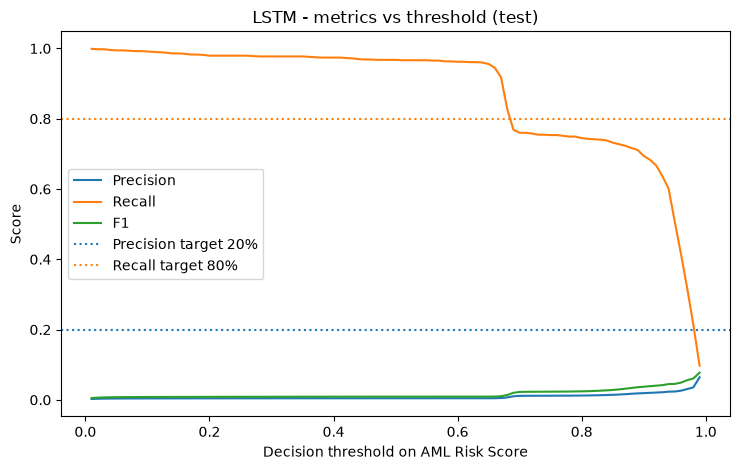

Sweep saved to: E:\AML-GNN-Project\results\lstm_threshold_sweep.csv


In [25]:
# =====================================================================================
# THRESHOLD SWEEP + operating point for the project goal  (Precision >= 20 %, Recall >= 80 %)
# Lowering the threshold catches more laundering (recall up) but flags more normal transactions (false positives up).
# The threshold is SELECTED on the validation slice and only REPORTED on the test set.
# =====================================================================================
SWEEP_THRESHOLDS = [0.50, 0.40, 0.30, 0.20, 0.10]
TARGET_PRECISION, TARGET_RECALL = 0.20, 0.80
y_test = y[test_idx]

def threshold_table(y_true, score, thresholds):
    rows = []
    for t in thresholds:
        r = evaluate_scores(y_true, score, t)
        r["Flagged (alerts)"] = r["TP"] + r["FP"]
        r["Alert Rate %"] = 100 * r["Flagged (alerts)"] / len(y_true)
        r["Meets P>=20% & R>=80%"] = bool(r["Precision"] >= TARGET_PRECISION and r["Recall"] >= TARGET_RECALL)
        rows.append(r)
    return pd.DataFrame(rows)[["Threshold", "TP", "FP", "FN", "TN", "Precision", "Recall", "F1-Score", "Accuracy",
                               "Flagged (alerts)", "Alert Rate %", "Meets P>=20% & R>=80%"]]

def select_threshold_for_targets(y_true, score):
    """Best-F1 threshold among those satisfying BOTH targets (computed on validation data). None if impossible."""
    p, r, t = precision_recall_curve(y_true, score)
    ok = np.where((p[:-1] >= TARGET_PRECISION) & (r[:-1] >= TARGET_RECALL))[0]
    if len(ok) == 0:
        return None
    f1 = 2 * p[:-1] * r[:-1] / np.clip(p[:-1] + r[:-1], 1e-12, None)
    return float(t[ok[np.argmax(f1[ok])]])

print("Score diagnostics (TEST):")
print(f"  median risk score - actual laundering: {np.median(score_test[y_test == 1]):.4f} | actual normal: {np.median(score_test[y_test == 0]):.4f}")
print(f"  share of laundering rows with score >= 0.50: {np.mean(score_test[y_test == 1] >= 0.5):.1%} | maximum score: {score_test.max():.4f}")

sweep_test = threshold_table(y_test, score_test, SWEEP_THRESHOLDS)
print("\nThreshold sweep on the TEST set (report only - not used to choose anything):")
display(sweep_test)
if VAL_HAS_BOTH:
    print("Threshold sweep on the VALIDATION slice (this is what threshold selection is based on):")
    display(threshold_table(y[val_idx], score_val, SWEEP_THRESHOLDS))

# ---- operating point chosen on validation ----
op_thr = select_threshold_for_targets(y[val_idx], score_val) if VAL_HAS_BOTH else None
if op_thr is None:
    print("\nNo validation threshold reaches Precision >= 20% AND Recall >= 80% together.")
else:
    print(f"\nValidation-selected threshold meeting both targets: {op_thr:.4f}")
    display(threshold_table(y_test, score_test, [op_thr]))
    all_metrics.append({"Model": MODEL_NAME, "Experiment": PRIMARY_LABEL, "Threshold Type": "validation-selected for P>=20% & R>=80%",
                        **evaluate_scores(y_test, score_test, op_thr)})

# ---- feasibility on test (oracle view, for diagnosis only) ----
p_c, r_c, _ = precision_recall_curve(y_test, score_test)
best_p_at_r = p_c[r_c >= TARGET_RECALL].max() if (r_c >= TARGET_RECALL).any() else 0.0
best_r_at_p = r_c[p_c >= TARGET_PRECISION].max() if (p_c >= TARGET_PRECISION).any() else 0.0
print(f"\nFeasibility on TEST (oracle, diagnosis only): best precision at recall >= 80% = {best_p_at_r:.1%} | best recall at precision >= 20% = {best_r_at_p:.1%}")
print("If both targets cannot be met at ANY threshold, the model's ranking is not good enough - changing the threshold cannot fix that.")

# ---- plot precision / recall / F1 versus threshold ----
grid = np.linspace(0.01, 0.99, 99)
curve = threshold_table(y_test, score_test, grid)
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(curve["Threshold"], curve["Precision"], label="Precision"); ax.plot(curve["Threshold"], curve["Recall"], label="Recall"); ax.plot(curve["Threshold"], curve["F1-Score"], label="F1")
ax.axhline(TARGET_PRECISION, color="tab:blue", ls=":", label="Precision target 20%"); ax.axhline(TARGET_RECALL, color="tab:orange", ls=":", label="Recall target 80%")
ax.set_xlabel("Decision threshold on AML Risk Score"); ax.set_ylabel("Score"); ax.set_title(f"{MODEL_NAME} - metrics vs threshold (test)"); ax.legend()
fig.tight_layout(); fig.savefig(RESULTS_DIR / f"{MODEL_SLUG}_threshold_sweep.png", dpi=150); plt.show()
sweep_test.to_csv(RESULTS_DIR / f"{MODEL_SLUG}_threshold_sweep.csv", index=False)
print("Sweep saved to:", RESULTS_DIR / f"{MODEL_SLUG}_threshold_sweep.csv")

In [26]:
# =====================================================================================
# Does the sparse late-date tail distort the test metrics?  (full test vs main period vs tail only)
# =====================================================================================
tail_test = is_sparse_tail[test_idx]
print(f"Test rows in the sparse tail: {int(tail_test.sum()):,} | laundering inside them: {int(y_test[tail_test].sum()):,} "
      f"of {int(y_test.sum()):,} test laundering rows ({100*y_test[tail_test].sum()/max(y_test.sum(),1):.1f}%)")
rows_cmp = []
for label, mask in [("Full test", np.ones(len(y_test), bool)), ("Main period only (tail excluded)", ~tail_test), ("Sparse tail only", tail_test)]:
    if mask.sum() == 0: continue
    r = evaluate_scores(y_test[mask], score_test[mask], THRESHOLD)
    rows_cmp.append({"Subset": label, "Rows": int(mask.sum()), "Laundering": int(y_test[mask].sum()), "Precision": r["Precision"], "Recall": r["Recall"],
                     "F1-Score": r["F1-Score"], "ROC-AUC": r["ROC-AUC"], "PR-AUC": r["PR-AUC"], "TP": r["TP"], "FP": r["FP"], "FN": r["FN"], "TN": r["TN"]})
    if label.startswith("Main"):
        all_metrics.append({"Model": MODEL_NAME, "Experiment": PRIMARY_LABEL, "Threshold Type": "fixed 0.50 | main period only", **r})
display(pd.DataFrame(rows_cmp))
print("If the main-period numbers are very different from the full-test numbers, the sparse tail (60 % laundering prevalence) is driving the headline metrics - report both.")

Test rows in the sparse tail: 223 | laundering inside them: 134 of 925 test laundering rows (14.5%)


,Subset,Rows,Laundering,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,TP,FP,FN,TN
0,Full test,1384810,925,0.004588,0.967568,0.009133,0.967009,0.046911,895,194166,30,1189719
1,Main period only (tail excluded),1384587,791,0.003905,0.962073,0.007779,0.962278,0.014696,761,194101,30,1189695
2,Sparse tail only,223,134,0.673367,1.000000,0.804805,0.894600,0.895015,134,65,0,24


If the main-period numbers are very different from the full-test numbers, the sparse tail (60 % laundering prevalence) is driving the headline metrics - report both.


CONFUSION MATRIX COUNTS at threshold 0.50 (primary model, test set)
  TP  true positives  (laundering correctly flagged)  : 895
  FP  false positives (normal wrongly flagged)         : 194,166
  FN  false negatives (laundering missed)              : 30
  TN  true negatives  (normal correctly passed)        : 1,189,719


,Pred Normal,Pred Laundering
Actual Normal,1189719,194166
Actual Laundering,30,895


THRESHOLD SWEEP | LSTM | LSTM


,Experiment,Threshold,TP,FP,FN,TN,Precision,Recall,F1-Score,Flagged,Meets P>=20% & R>=80%
0,LSTM,0.900000,642,32793,283,1351092,0.019201,0.694054,0.037369,33435,False
1,LSTM,0.700000,703,60428,222,1323457,0.011500,0.760000,0.022657,61131,False
2,LSTM,0.500000,895,194166,30,1189719,0.004588,0.967568,0.009133,195061,False
3,LSTM,0.400000,901,197528,24,1186357,0.004541,0.974054,0.009039,198429,False
4,LSTM,0.300000,904,202072,21,1181813,0.004454,0.977297,0.008867,202976,False
5,LSTM,0.200000,906,209305,19,1174580,0.004310,0.979459,0.008582,210211,False
6,LSTM,0.100000,917,222384,8,1161501,0.004107,0.991351,0.008179,223301,False
7,LSTM,0.050000,920,239016,5,1144869,0.003834,0.994595,0.007639,239936,False
8,LSTM,0.020000,923,288636,2,1095249,0.003188,0.997838,0.006355,289559,False


Best precision on test while keeping recall >= 80%: 0.0087  -> the target precision of 20% is NOT reachable for this model with ANY threshold.
Validation-selected operating threshold = 0.6816 (highest threshold with validation recall >= 80%)
   -> on TEST: Precision 0.0074 | Recall 0.8184 | F1 0.0147 | TP 757 FP 101,315 FN 168 TN 1,282,570


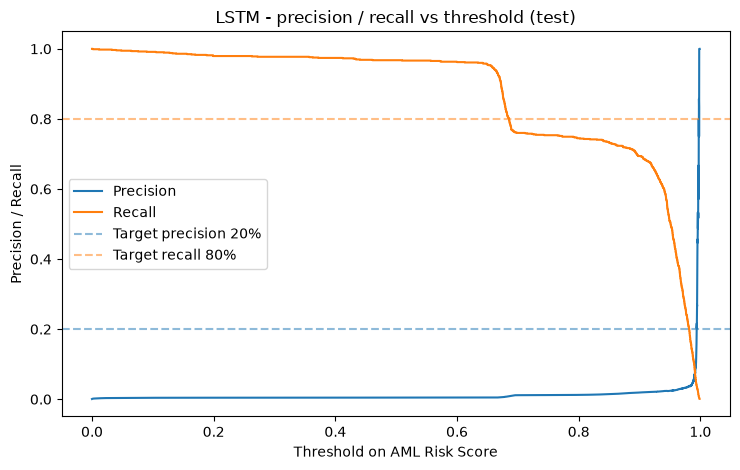


Metrics by test subset (threshold 0.50):


,Subset,Rows,Laundering,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Full test set,1384810,925,0.500000,0.859767,0.004588,0.967568,0.009133,0.967009,0.046911,1189719,194166,30,895
1,Main window only (normal-traffic days),1384587,791,0.500000,0.859791,0.003905,0.962073,0.007779,0.962278,0.014696,1189695,194101,30,761
2,Thin-tail days only,223,134,0.500000,0.708520,0.673367,1.000000,0.804805,0.894600,0.895015,24,65,0,134



Test-set results per day:


,Rows,Laundering,Flagged,TP,FP,FN
Date,,,,,,
2022-09-08,210137,123,28101,118,27983,5
2022-09-09,891573,367,123307,351,122956,16
2022-09-10,282877,301,43454,292,43162,9
2022-09-11,77,47,65,47,18,0
2022-09-12,48,27,44,27,17,0
2022-09-13,48,29,43,29,14,0
2022-09-14,31,18,28,18,10,0
2022-09-15,9,6,9,6,3,0
2022-09-16,7,5,7,5,2,0


In [27]:
sweep_inputs = {'LSTM': (score_val, score_test)}

# =====================================================================================
# CONFUSION-MATRIX COUNTS, THRESHOLD SWEEP, TARGET CHECK, PER-PERIOD BREAKDOWN
# NOTE: the sweep below is DESCRIPTIVE (it shows what each threshold would do on the test set).
# The operating threshold must be CHOSEN on the validation slice - choosing it on test would leak test information.
# Changing the threshold never changes ROC-AUC / PR-AUC: it only moves along the precision-recall trade-off.
# =====================================================================================
y_test = y[test_idx]
tn, fp, fn, tp = confusion_matrix(y_test, (score_test >= THRESHOLD).astype(int), labels=[0, 1]).ravel()
print(f"CONFUSION MATRIX COUNTS at threshold {THRESHOLD:.2f} (primary model, test set)")
print(f"  TP  true positives  (laundering correctly flagged)  : {tp:,}")
print(f"  FP  false positives (normal wrongly flagged)         : {fp:,}")
print(f"  FN  false negatives (laundering missed)              : {fn:,}")
print(f"  TN  true negatives  (normal correctly passed)        : {tn:,}")
display(pd.DataFrame([[tn, fp], [fn, tp]], index=["Actual Normal", "Actual Laundering"], columns=["Pred Normal", "Pred Laundering"]))

sweep_frames = []
for exp_name, (s_val_, s_test_) in sweep_inputs.items():
    print("=" * 100); print(f"THRESHOLD SWEEP | {MODEL_NAME} | {exp_name}"); print("=" * 100)
    sw = threshold_sweep(y_test, s_test_)
    sw.insert(0, "Experiment", exp_name); sweep_frames.append(sw)
    display(sw)
    p_, r_, t_ = precision_recall_curve(y_test, s_test_)
    feasible = p_[r_ >= TARGET_RECALL]
    best_p = float(feasible.max()) if len(feasible) else float("nan")
    verdict = "reachable" if best_p >= TARGET_PRECISION else "NOT reachable"
    print(f"Best precision on test while keeping recall >= {TARGET_RECALL:.0%}: {best_p:.4f}  -> the target precision of {TARGET_PRECISION:.0%} is {verdict} for this model with ANY threshold.")
    if VAL_HAS_BOTH:
        thr_v = pick_threshold_for_recall(y[val_idx], s_val_)
        how = f"highest threshold with validation recall >= {TARGET_RECALL:.0%}"
        if thr_v is None:
            thr_v, how = best_f1_threshold(y[val_idx], s_val_), "best-F1 on validation (recall target not reachable on validation)"
        r = evaluate_scores(y_test, s_test_, thr_v)
        print(f"Validation-selected operating threshold = {thr_v:.4f} ({how})")
        print(f"   -> on TEST: Precision {r['Precision']:.4f} | Recall {r['Recall']:.4f} | F1 {r['F1-Score']:.4f} | TP {r['TP']:,} FP {r['FP']:,} FN {r['FN']:,} TN {r['TN']:,}")

sweep_df = pd.concat(sweep_frames, ignore_index=True)
sweep_df.to_csv(RESULTS_DIR / f"{MODEL_SLUG}_threshold_sweep.csv", index=False)
save_threshold_tradeoff(y_test, score_test, RESULTS_DIR / f"{MODEL_SLUG}_threshold_tradeoff.png", f"{MODEL_NAME} - precision / recall vs threshold (test)")

# ---- is the performance coming from the main window or from the thin tail? ----
pred_primary = (score_test >= THRESHOLD).astype(int)
thin_test = is_thin_row[test_idx]
masks = {"Full test set": np.ones(len(test_idx), dtype=bool), "Main window only (normal-traffic days)": ~thin_test, "Thin-tail days only": thin_test}
sub_df = subset_metrics(y_test, score_test, masks, THRESHOLD)
print("\nMetrics by test subset (threshold %.2f):" % THRESHOLD)
display(sub_df)
sub_df.to_csv(RESULTS_DIR / f"{MODEL_SLUG}_metrics_by_subset.csv", index=False)

pdf = pd.DataFrame({"Date": pd.to_datetime(day_num[test_idx] * 86400, unit="s").date, "y": y_test, "pred": pred_primary})
pdf["TP"] = ((pdf.y == 1) & (pdf.pred == 1)).astype(int); pdf["FP"] = ((pdf.y == 0) & (pdf.pred == 1)).astype(int); pdf["FN"] = ((pdf.y == 1) & (pdf.pred == 0)).astype(int)
per_day = pdf.groupby("Date").agg(Rows=("y", "size"), Laundering=("y", "sum"), Flagged=("pred", "sum"), TP=("TP", "sum"), FP=("FP", "sum"), FN=("FN", "sum"))
print("\nTest-set results per day:")
display(per_day)
per_day.to_csv(RESULTS_DIR / f"{MODEL_SLUG}_test_results_per_day.csv")

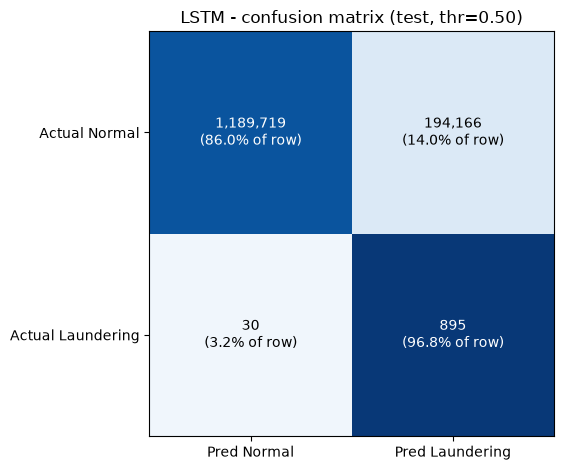

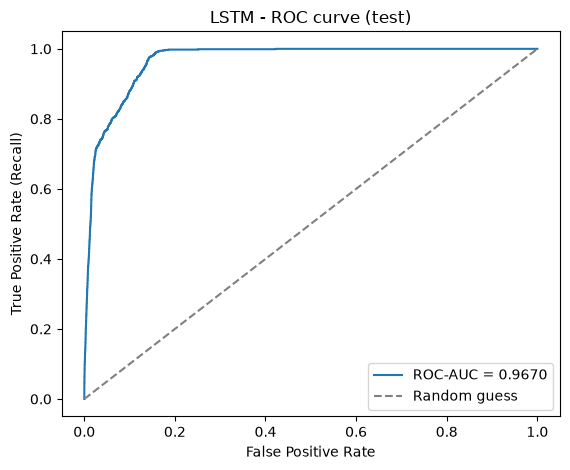

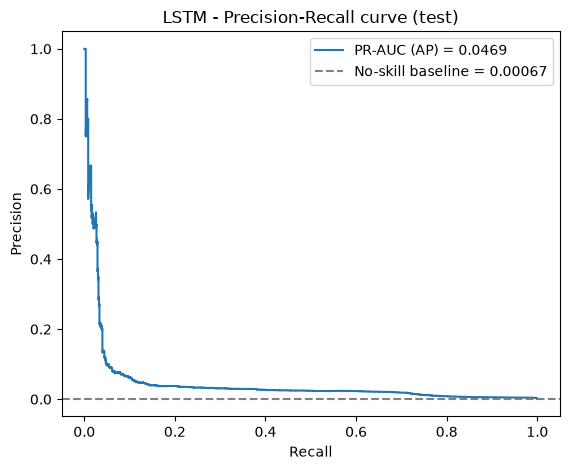

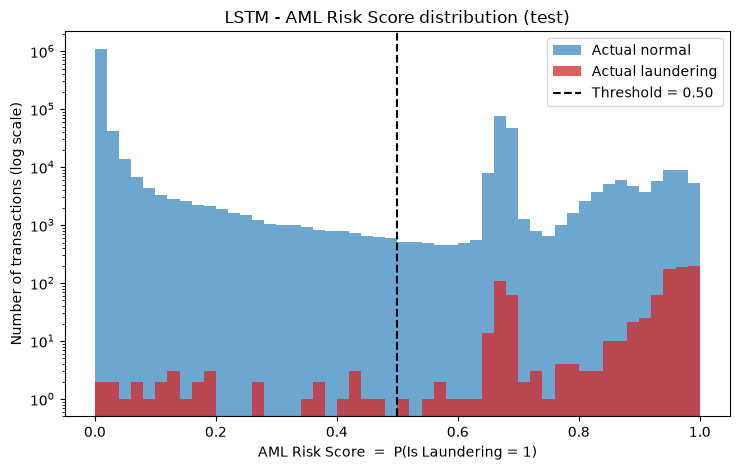

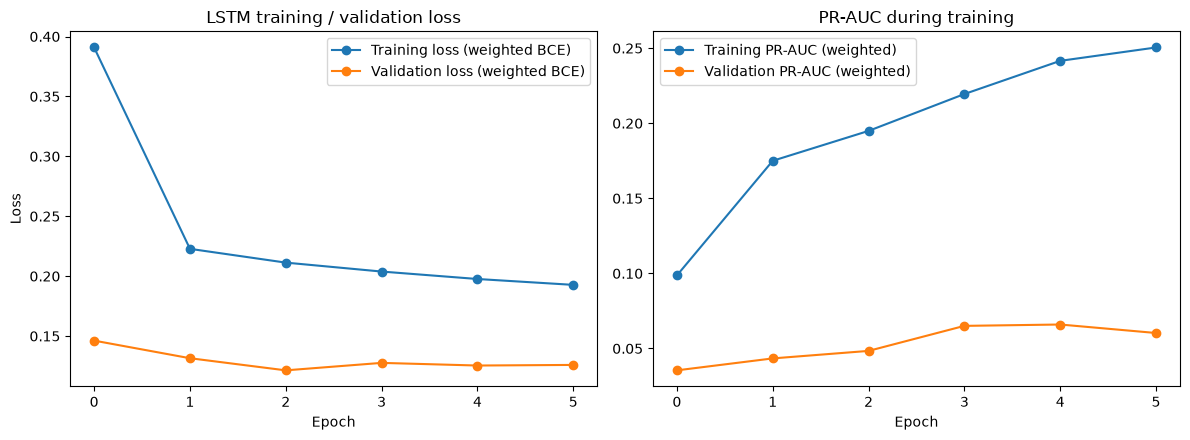

In [28]:
save_confusion_matrix(y_test, pred_primary, RESULTS_DIR / "lstm_confusion_matrix.png", "LSTM - confusion matrix (test, thr=0.50)")
save_roc_curve(y_test, score_test, RESULTS_DIR / "lstm_roc_curve.png", "LSTM - ROC curve (test)")
save_pr_curve(y_test, score_test, RESULTS_DIR / "lstm_pr_curve.png", "LSTM - Precision-Recall curve (test)")
save_risk_distribution(y_test, score_test, RESULTS_DIR / "lstm_risk_distribution.png", "LSTM - AML Risk Score distribution (test)", THRESHOLD)

h = history.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(h["loss"], marker="o", label="Training loss (weighted BCE)")
axes[0].plot(h["val_loss"], marker="o", label="Validation loss (weighted BCE)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("LSTM training / validation loss"); axes[0].legend()
if "pr_auc" in h:
    axes[1].plot(h["pr_auc"], marker="o", label="Training PR-AUC (weighted)"); axes[1].plot(h.get("val_pr_auc", []), marker="o", label="Validation PR-AUC (weighted)")
    axes[1].set_xlabel("Epoch"); axes[1].set_title("PR-AUC during training"); axes[1].legend()
fig.tight_layout(); fig.savefig(RESULTS_DIR / "lstm_training_history.png", dpi=150); plt.show()

In [29]:
MODEL_PATH = MODELS_DIR / "lstm_model.keras"
model.save(MODEL_PATH)
joblib.dump({"feature_names": FEATURE_NAMES, "cont_cols": CONT_COLS, "scaler_mean": mu, "scaler_std": sd, "payment_format_levels": fmt_levels,
             "sequence_length": SEQUENCE_LENGTH, "class_weights": CLASS_WEIGHTS, "threshold": THRESHOLD, "windows_seconds": WINDOWS},
            MODELS_DIR / "lstm_preprocessing.pkl")
print("Model saved to:", MODEL_PATH)

Model saved to: E:\AML-GNN-Project\models\lstm_model.keras


In [30]:
PRED_PATH = OUTPUTS_DIR / "lstm_predictions.csv"
pred_table.to_csv(PRED_PATH, index=False)
print("Predictions saved to:", PRED_PATH, "| rows:", len(pred_table))

Predictions saved to: E:\AML-GNN-Project\outputs\lstm_predictions.csv | rows: 1384810


In [31]:
metrics_df = pd.DataFrame(all_metrics)
metrics_df["Train Rows Used"] = len(fit_idx); metrics_df["Test Rows"] = len(test_idx)
metrics_df["Split Mode"] = SPLIT_MODE; metrics_df["Sequence Length"] = SEQUENCE_LENGTH
METRICS_PATH = RESULTS_DIR / "lstm_metrics.csv"
metrics_df.to_csv(METRICS_PATH, index=False)
print("Metrics saved to:", METRICS_PATH)

Metrics saved to: E:\AML-GNN-Project\results\lstm_metrics.csv


In [32]:
# LI-Small_Patterns.txt is NOT a one-row-per-transaction CSV. It is a separate pattern-analysis / validation resource.
# We only inspect it here (count the pattern types). We deliberately do NOT merge it into the feature matrix and
# we do NOT invent transaction-level pattern labels.
if PATH_PATTERNS.exists():
    begin_re = re.compile(r"BEGIN LAUNDERING ATTEMPT\s*-\s*([A-Za-z0-9\-_ ]+?)\s*(?::|$)", re.I)
    pattern_counts, preview, n_lines = {}, [], 0
    with open(PATH_PATTERNS, "r", errors="ignore") as fh:
        for line in fh:
            n_lines += 1
            if len(preview) < 12:
                preview.append(line.rstrip())
            m = begin_re.search(line)
            if m:
                k = m.group(1).strip().upper()
                pattern_counts[k] = pattern_counts.get(k, 0) + 1
    print(f"Patterns file: {n_lines:,} lines")
    print("First lines:"); print("\n".join("   " + p for p in preview))
    if pattern_counts:
        print("\nLaundering-attempt blocks per pattern type:")
        display(pd.Series(pattern_counts, name="Attempts").sort_values(ascending=False).to_frame())
    else:
        print("No 'BEGIN LAUNDERING ATTEMPT' headers recognised - inspect the file format manually.")
else:
    print("Patterns file not found - skipping (it is not required for training).")

Patterns file: 1,374 lines
First lines:
   BEGIN LAUNDERING ATTEMPT - FAN-IN:  Max 3-degree Fan-In
   2022/09/01 02:38,001812,80279F810,0110,8000A94C0,10154.74,Australian Dollar,10154.74,Australian Dollar,ACH,1
   2022/09/02 14:36,022595,80279F8B0,0110,8000A94C0,5326.79,Australian Dollar,5326.79,Australian Dollar,ACH,1
   2022/09/03 14:09,001120,800E36A50,0110,8000A94C0,4634.81,Australian Dollar,4634.81,Australian Dollar,ACH,1
   END LAUNDERING ATTEMPT - FAN-IN
   
   BEGIN LAUNDERING ATTEMPT - FAN-IN:  Max 8-degree Fan-In
   2022/09/01 03:17,003671,801BF8E70,002557,8016B3750,8099.96,Euro,8099.96,Euro,ACH,1
   2022/09/01 06:27,015,80074C7E0,002557,8016B3750,10468.56,Euro,10468.56,Euro,ACH,1
   2022/09/01 10:04,002557,80107C9A0,002557,8016B3750,10270.07,Euro,10270.07,Euro,ACH,1
   2022/09/02 06:35,012,800A9B180,002557,8016B3750,15645.21,Euro,15645.21,Euro,ACH,1
   2022/09/03 09:12,021393,801271170,002557,8016B3750,14139.75,Euro,14139.75,Euro,ACH,1

Laundering-attempt blocks per pattern 

,Attempts
FAN-OUT,19
STACK,18
BIPARTITE,16
RANDOM,15
SCATTER-GATHER,13
GATHER-SCATTER,12
FAN-IN,12
CYCLE,12


In [33]:
m = metrics_df[(metrics_df["Experiment"] == PRIMARY_LABEL) & (metrics_df["Threshold Type"] == "fixed 0.50")].iloc[0]
summary_table = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC", "True Positives (TP)", "True Negatives (TN)", "False Positives (FP)", "False Negatives (FN)"],
                              "Value": [m["Accuracy"], m["Precision"], m["Recall"], m["F1-Score"], m["ROC-AUC"], m["PR-AUC"], int(m["TP"]), int(m["TN"]), int(m["FP"]), int(m["FN"])]})
print("Model: LSTM  (threshold 0.50, chronological test set)")
display(summary_table)

print("=" * 40); print("MODEL: LSTM"); print("=" * 40)
print(f"Split mode            : {SPLIT_MODE}")
print(f"Sequence length       : {SEQUENCE_LENGTH}")
print(f"Train samples (total) : {len(train_idx):,}   (sequences actually used to fit: {len(fit_idx):,})")
print(f"Test samples          : {len(test_idx):,}")
print(f"Laundering in train   : {int(y[train_idx].sum()):,}")
print(f"Laundering in test    : {int(y[test_idx].sum()):,}")
print(f"Accuracy  : {m['Accuracy']:.4f}"); print(f"Precision : {m['Precision']:.4f}"); print(f"Recall    : {m['Recall']:.4f}")
print(f"F1 Score  : {m['F1-Score']:.4f}"); print(f"ROC-AUC   : {m['ROC-AUC']:.4f}"); print(f"PR-AUC    : {m['PR-AUC']:.4f}")
print(f"TP: {int(m['TP']):,} | TN: {int(m['TN']):,} | FP: {int(m['FP']):,} | FN: {int(m['FN']):,}")
print(f"Validation-selected threshold for Precision>=20% & Recall>=80%: {op_thr if op_thr is not None else 'none found'}")
print(f"TP: {int(m['TP']):,} | FP: {int(m['FP']):,} | FN: {int(m['FN']):,} | TN: {int(m['TN']):,}   (threshold 0.50)")
print(f"Average AML Risk Score : {score_test.mean():.4f}"); print(f"Highest AML Risk Score : {score_test.max():.4f}")
print("Model saved to       :", MODEL_PATH); print("Predictions saved to :", PRED_PATH); print("Metrics saved to     :", METRICS_PATH)
if SPLIT_MODE != "chronological":
    print("\n*** WARNING: fallback random split was used - NOT a true future-prediction evaluation. ***")

Model: LSTM  (threshold 0.50, chronological test set)


,Metric,Value
0,Accuracy,0.859767
1,Precision,0.004588
2,Recall,0.967568
3,F1-Score,0.009133
4,ROC-AUC,0.967009
5,PR-AUC,0.046911
6,True Positives (TP),895.000000
7,True Negatives (TN),"1,189,719.000000"
8,False Positives (FP),"194,166.000000"
9,False Negatives (FN),30.000000


MODEL: LSTM
Split mode            : chronological
Sequence length       : 10
Train samples (total) : 5,539,239   (sequences actually used to fit: 302,314)
Test samples          : 1,384,810
Laundering in train   : 2,640
Laundering in test    : 925
Accuracy  : 0.8598
Precision : 0.0046
Recall    : 0.9676
F1 Score  : 0.0091
ROC-AUC   : 0.9670
PR-AUC    : 0.0469
TP: 895 | TN: 1,189,719 | FP: 194,166 | FN: 30
Validation-selected threshold for Precision>=20% & Recall>=80%: none found
TP: 895 | FP: 194,166 | FN: 30 | TN: 1,189,719   (threshold 0.50)
Average AML Risk Score : 0.1134
Highest AML Risk Score : 0.9987
Model saved to       : E:\AML-GNN-Project\models\lstm_model.keras
Predictions saved to : E:\AML-GNN-Project\outputs\lstm_predictions.csv
Metrics saved to     : E:\AML-GNN-Project\results\lstm_metrics.csv


In [34]:
# ============================================================================================
# THRESHOLD STUDY  (cell 1 of 4): run thresholds 0.50, 0.40, 0.30, 0.20, 0.10 one after another
# Rule applied each time:  AML Risk Score >= threshold  ->  predicted laundering (1), else normal (0)
# ============================================================================================
THRESHOLDS = [0.50, 0.40, 0.30, 0.20, 0.10]
y_test = y[test_idx]                       # true labels of the (untouched) test set
threshold_rows = []

for thr in THRESHOLDS:
    pred = (score_test >= thr).astype(int)
    m = evaluate_scores(y_test, score_test, thr)           # Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, TN, FP, FN, TP
    m["Flagged"] = m["TP"] + m["FP"]
    m["Flagged % of test"] = 100 * m["Flagged"] / len(y_test)
    threshold_rows.append(m)

    print("=" * 78)
    print(f"{MODEL_NAME.upper()}  |  THRESHOLD = {thr:.2f}")
    print("=" * 78)
    print(f"TP (laundering caught)  : {m['TP']:,}")
    print(f"FP (normal flagged)     : {m['FP']:,}")
    print(f"FN (laundering missed)  : {m['FN']:,}")
    print(f"TN (normal passed)      : {m['TN']:,}")
    print(f"Transactions flagged    : {m['Flagged']:,}  ({m['Flagged % of test']:.2f}% of the test set)")
    print(f"Accuracy {m['Accuracy']:.4f} | Precision {m['Precision']:.4f} | Recall {m['Recall']:.4f} | "
          f"F1 {m['F1-Score']:.4f} | ROC-AUC {m['ROC-AUC']:.4f} | PR-AUC {m['PR-AUC']:.4f}")
    print(classification_report(y_test, pred, target_names=["Normal (0)", "Laundering (1)"], digits=4, zero_division=0))

LSTM  |  THRESHOLD = 0.50
TP (laundering caught)  : 895
FP (normal flagged)     : 194,166
FN (laundering missed)  : 30
TN (normal passed)      : 1,189,719
Transactions flagged    : 195,061  (14.09% of the test set)
Accuracy 0.8598 | Precision 0.0046 | Recall 0.9676 | F1 0.0091 | ROC-AUC 0.9670 | PR-AUC 0.0469
                precision    recall  f1-score   support

    Normal (0)     1.0000    0.8597    0.9245   1383885
Laundering (1)     0.0046    0.9676    0.0091       925

      accuracy                         0.8598   1384810
     macro avg     0.5023    0.9136    0.4668   1384810
  weighted avg     0.9993    0.8598    0.9239   1384810

LSTM  |  THRESHOLD = 0.40
TP (laundering caught)  : 901
FP (normal flagged)     : 197,528
FN (laundering missed)  : 24
TN (normal passed)      : 1,186,357
Transactions flagged    : 198,429  (14.33% of the test set)
Accuracy 0.8573 | Precision 0.0045 | Recall 0.9741 | F1 0.0090 | ROC-AUC 0.9670 | PR-AUC 0.0469
                precision    recall  f1

In [35]:
# ============================================================================================
# THRESHOLD STUDY (cell 2 of 4): comparison table
# ============================================================================================
thr_df = pd.DataFrame(threshold_rows)[["Threshold", "TP", "FP", "FN", "TN", "Flagged", "Flagged % of test",
                                       "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]]
thr_df[f"Recall >= {TARGET_RECALL:.0%}?"] = thr_df["Recall"] >= TARGET_RECALL
thr_df[f"Precision >= {TARGET_PRECISION:.0%}?"] = thr_df["Precision"] >= TARGET_PRECISION
thr_df["Meets BOTH targets?"] = thr_df.iloc[:, -1] & thr_df.iloc[:, -2]

display(thr_df.set_index("Threshold"))
thr_df.to_csv(RESULTS_DIR / f"{MODEL_SLUG}_threshold_comparison.csv", index=False)
print("Saved:", RESULTS_DIR / f"{MODEL_SLUG}_threshold_comparison.csv")
print("\nNOTE: ROC-AUC and PR-AUC are IDENTICAL for every threshold - they measure how well the scores RANK transactions,")
print("so changing the threshold cannot change them. Only TP/FP/FN/TN, Precision, Recall, F1 and Accuracy move.")

,TP,FP,FN,TN,Flagged,Flagged % of test,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Recall >= 80%?,Precision >= 20%?,Meets BOTH targets?
Threshold,,,,,,,,,,,,,,,
0.500000,895,194166,30,1189719,195061,14.085759,0.859767,0.004588,0.967568,0.009133,0.967009,0.046911,True,False,False
0.400000,901,197528,24,1186357,198429,14.328969,0.857344,0.004541,0.974054,0.009039,0.967009,0.046911,True,False,False
0.300000,904,202072,21,1181813,202976,14.657318,0.854064,0.004454,0.977297,0.008867,0.967009,0.046911,True,False,False
0.200000,906,209305,19,1174580,210211,15.179772,0.848843,0.004310,0.979459,0.008582,0.967009,0.046911,True,False,False
0.100000,917,222384,8,1161501,223301,16.125028,0.839406,0.004107,0.991351,0.008179,0.967009,0.046911,True,False,False


Saved: E:\AML-GNN-Project\results\lstm_threshold_comparison.csv

NOTE: ROC-AUC and PR-AUC are IDENTICAL for every threshold - they measure how well the scores RANK transactions,
so changing the threshold cannot change them. Only TP/FP/FN/TN, Precision, Recall, F1 and Accuracy move.


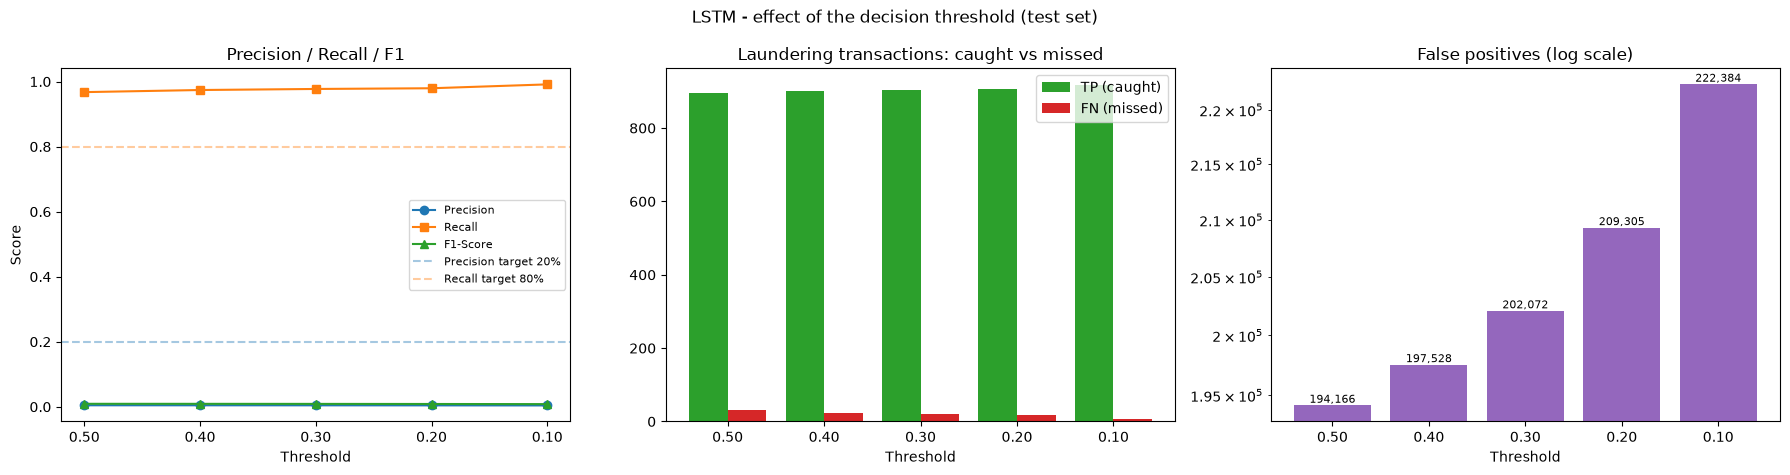

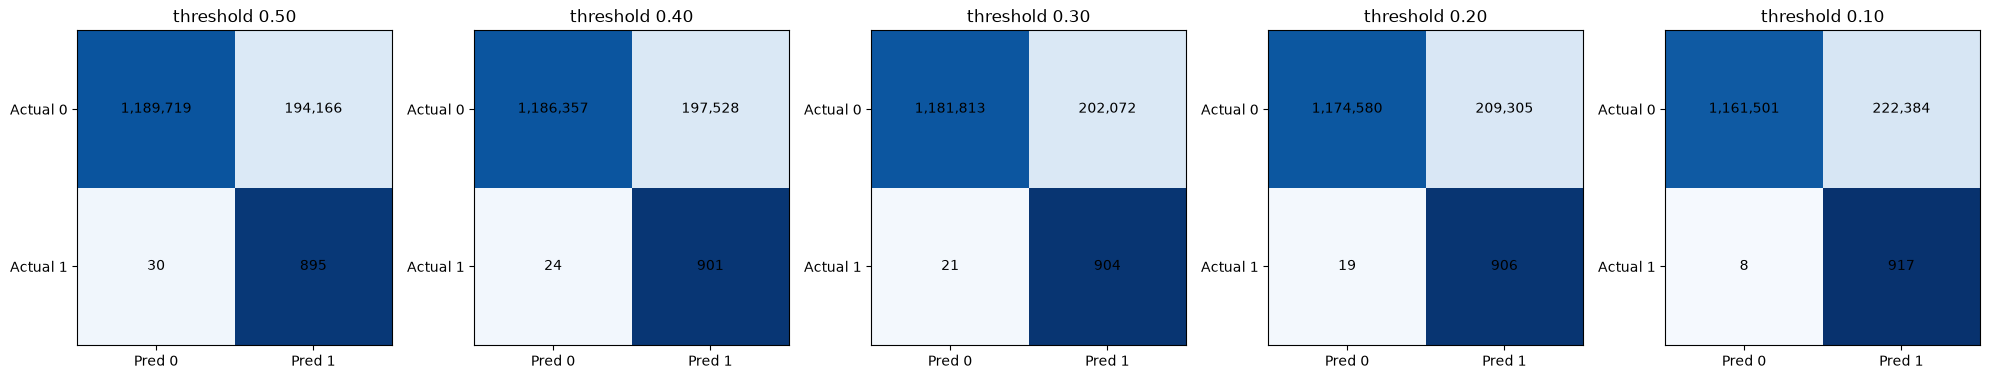

In [36]:
# ============================================================================================
# THRESHOLD STUDY (cell 3 of 4): charts comparing the five thresholds
# ============================================================================================
x = np.arange(len(thr_df)); labels = [f"{t:.2f}" for t in thr_df["Threshold"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
# (a) precision / recall / F1 against threshold
for col, mk in [("Precision", "o"), ("Recall", "s"), ("F1-Score", "^")]:
    axes[0].plot(labels, thr_df[col], marker=mk, label=col)
axes[0].axhline(TARGET_PRECISION, ls="--", color="tab:blue", alpha=0.4, label=f"Precision target {TARGET_PRECISION:.0%}")
axes[0].axhline(TARGET_RECALL, ls="--", color="tab:orange", alpha=0.4, label=f"Recall target {TARGET_RECALL:.0%}")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score"); axes[0].set_title("Precision / Recall / F1"); axes[0].legend(fontsize=8)
# (b) laundering caught vs missed
axes[1].bar(x - 0.2, thr_df["TP"], 0.4, label="TP (caught)", color="tab:green")
axes[1].bar(x + 0.2, thr_df["FN"], 0.4, label="FN (missed)", color="tab:red")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels); axes[1].set_xlabel("Threshold"); axes[1].set_title("Laundering transactions: caught vs missed"); axes[1].legend()
# (c) cost of the extra recall: false positives
axes[2].bar(x, thr_df["FP"], color="tab:purple")
axes[2].set_yscale("log"); axes[2].set_xticks(x); axes[2].set_xticklabels(labels)
axes[2].set_xlabel("Threshold"); axes[2].set_title("False positives (log scale)")
for i, v in enumerate(thr_df["FP"]):
    axes[2].text(i, max(v, 1), f"{v:,}", ha="center", va="bottom", fontsize=8)
fig.suptitle(f"{MODEL_NAME} - effect of the decision threshold (test set)")
fig.tight_layout(); fig.savefig(RESULTS_DIR / f"{MODEL_SLUG}_threshold_comparison.png", dpi=150); plt.show()

# confusion matrices side by side
fig, axes = plt.subplots(1, len(thr_df), figsize=(4 * len(thr_df), 3.8))
for ax, (_, r) in zip(axes, thr_df.iterrows()):
    cm = np.array([[r["TN"], r["FP"]], [r["FN"], r["TP"]]], dtype=float)
    ax.imshow(cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None), cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{int(cm[i, j]):,}", ha="center", va="center", fontsize=10, color="black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"]); ax.set_yticklabels(["Actual 0", "Actual 1"])
    ax.set_title(f"threshold {r['Threshold']:.2f}")
fig.tight_layout(); fig.savefig(RESULTS_DIR / f"{MODEL_SLUG}_threshold_confusion_matrices.png", dpi=150); plt.show()

In [37]:
# ============================================================================================
# THRESHOLD STUDY (cell 4 of 4): conclusion
# ============================================================================================
best_f1 = thr_df.loc[thr_df["F1-Score"].idxmax()]
print(f"Best F1 among the five thresholds      : {best_f1['Threshold']:.2f}  (F1 {best_f1['F1-Score']:.4f}, precision {best_f1['Precision']:.4f}, recall {best_f1['Recall']:.4f})")
rec_ok = thr_df[thr_df["Recall"] >= TARGET_RECALL]
if len(rec_ok):
    hp = rec_ok.loc[rec_ok["Precision"].idxmax()]
    print(f"Highest threshold reaching recall >= {TARGET_RECALL:.0%}: {rec_ok['Threshold'].max():.2f}")
    print(f"   best precision while recall >= {TARGET_RECALL:.0%}: {hp['Precision']:.4f} at threshold {hp['Threshold']:.2f} "
          f"(flags {int(hp['Flagged']):,} transactions for {int(hp['TP']):,} true catches)")
else:
    print(f"No threshold among the five reaches recall >= {TARGET_RECALL:.0%} (best recall {thr_df['Recall'].max():.4f} at {thr_df.loc[thr_df['Recall'].idxmax(), 'Threshold']:.2f}).")
both = thr_df[thr_df["Meets BOTH targets?"]]
if len(both):
    print(f"\nTARGET MET (precision >= {TARGET_PRECISION:.0%} AND recall >= {TARGET_RECALL:.0%}) at thresholds: {list(both['Threshold'])}")
else:
    print(f"\nTARGET NOT MET: no threshold achieves precision >= {TARGET_PRECISION:.0%} AND recall >= {TARGET_RECALL:.0%} together.")
    print(f"Highest precision seen: {thr_df['Precision'].max():.4f} | highest recall seen: {thr_df['Recall'].max():.4f}")
    print("Lowering the threshold only trades precision for recall; if PR-AUC is low, a better model/features are needed, not a different threshold.")

# Honest way to pick an operating threshold: on the VALIDATION slice, never on the test set
s_val_ = primary["s_val"] if "primary" in globals() else score_val
if VAL_HAS_BOTH:
    thr_v = pick_threshold_for_recall(y[val_idx], s_val_)
    if thr_v is not None:
        r = evaluate_scores(y_test, score_test, thr_v)
        print(f"\nValidation-selected threshold (highest with validation recall >= {TARGET_RECALL:.0%}) = {thr_v:.4f}")
        print(f"   applied to TEST -> Precision {r['Precision']:.4f} | Recall {r['Recall']:.4f} | TP {r['TP']:,} FP {r['FP']:,} FN {r['FN']:,} TN {r['TN']:,}")
    else:
        print("\nOn validation, no threshold reaches the recall target.")
print("\nReminder: the table above is computed ON TEST for description. Do not pick your final threshold from it.")

Best F1 among the five thresholds      : 0.50  (F1 0.0091, precision 0.0046, recall 0.9676)
Highest threshold reaching recall >= 80%: 0.50
   best precision while recall >= 80%: 0.0046 at threshold 0.50 (flags 195,061 transactions for 895 true catches)

TARGET NOT MET: no threshold achieves precision >= 20% AND recall >= 80% together.
Highest precision seen: 0.0046 | highest recall seen: 0.9914
Lowering the threshold only trades precision for recall; if PR-AUC is low, a better model/features are needed, not a different threshold.

Validation-selected threshold (highest with validation recall >= 80%) = 0.6816
   applied to TEST -> Precision 0.0074 | Recall 0.8184 | TP 757 FP 101,315 FN 168 TN 1,282,570

Reminder: the table above is computed ON TEST for description. Do not pick your final threshold from it.
